Nathaniel Linden-Santangeli 2025

### Prior predictive elicitation for AMPK models

##### Background

Inference for the AMPK models with wide relatively un-informed priors is challenging, with posteriors often failing to capture the appropriate sigmoidal responses seen in the data (as of 1/16/2025). The `../test_models_and_mass_conservation/explore_sensor_model.ipynb` notebook uses a simple sensor model with a time-dependent phosphorylation rate to determine what features of the phosphorylation rate are needed to achieve sigmoidal sensor responses. In particular we found the following

1. The initial phosphorylation rate must be zero (or very small relative to the dephosphorylation rate) to achieve the slow initial rise in the sensor response.
2. Increasing phosphorylation rates give rise to the increasing slope of the sensor response after the initial slow activation.
3. Increased dephosphorylation rates can slow down sensor activation, but also decrease the steady-state response. Higher phosphorylation rates can counteract this effect, but they speed of the overall response.

Therefore, we need to assign priors to the AMPK models that lead to slow initial activation, followed by a rapid increase in activation, and a steady-state response that fully activates the sensor.

##### Direct prior elicitation - maximum entropy priors

Direct elicitation aims to assign prior parameters such that the prior mass is between specified ranges. See [Preliz - Direct elicitation in 1D](https://preliz.readthedocs.io/en/latest/examples/Direct_elicitation_in_1D.html) for details on the approach. We specified the bounds by multiplying literature values of each parameter by a factor of 1e4 and 1e-3 (or smh similar).

##### Predictive prior elicitation
We previously used *maximum entropy* elicitation to find parameter for prior densities such that the prior mass was between specified ranges. See [Preliz - Direct elicitation in 1D](https://preliz.readthedocs.io/en/latest/examples/Direct_elicitation_in_1D.html) for details on the approach. We specified the bounds by multiplying literature values of each parameter by a factor of 1e4 and 1e-3 (or smh similar). However this approach led to priors that are far too wide and sometimes place little to know prior mass on the appropriate parameter ranges.

**Predictive** prior elicitation is based on the idea of choosing prior parameters such that the prior predictive density *makes sense* or contains predictions that agree with our expectations of the model. See [Preliz - predictive elicitation](https://preliz.readthedocs.io/en/latest/examples/predictive_elicitation.html) for more details.

This reference [Prior knowledge elicitation: The past, present, and future](https://projecteuclid.org/journals/bayesian-analysis/advance-publication/Prior-Knowledge-Elicitation-The-Past-Present-and-Future/10.1214/23-BA1381.full) provides a nice overview of the concepts of prior elicitation

##### Goals of this notebook
1. Set up predictive elicitation for the AMPK models such that we are able to tune prior parameters to achieve prior predictive densities that are reasonable.
2. Obtain refined prior parameters for the AMPK models that lead to reasonable prior predictive densities which can be justified by the fact that they provide reasonable *a priori* predictions of the sensor response.

In [1]:
# imports
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pymc.sampling.jax import sample_numpyro_nuts, get_jaxified_logp
# import nutpie
from pymc.variational.callbacks import CheckParametersConvergence
from pytensor.link.jax.dispatch import jax_funcify
from pymc.stats.log_density import compute_log_likelihood
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
import time

from jax import random
import arviz as az
from numpyro.infer import Predictive
import sys, argparse, json, os
import matplotlib.pyplot as plt
import seaborn as sns
import met_brewer as mb

sys.path.append("../")
from utils import *
from pymc_jax_ode import *

sys.path.append("../models/")

# tell jax to use 64bit floats
jax.config.update('jax_platform_name', 'cpu')
jax.config.update("jax_enable_x64", True)

plt.style.use("~/.matplotlib/stylelib/custom.mplstyle")

savedir = '../../../results/param_est/prior_predictive/'

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
# set up models - use the MA single and MM single models
from MA_single_diffrax import *
from MM_single_diffrax import *

MA_info = json.load(open('../models/MA_single.json'))
MM_info = json.load(open('../models/MM_single.json'))

# get initial conditions
y0_MA = list(MA_info['init_conds'].values())
y0_MM = list(MM_info['init_conds'].values())

# deal with getting AMPKAR idxs
state_names_MA = list(MA_info["init_conds"].keys()) # MA
ampkar_states_MA = MA_info['ampkar_states']
pampkar_states_MA = MA_info['pampkar_states']
ampkar_idxs_MA = [state_names_MA.index(item) for item in ampkar_states_MA]
pampkar_idxs_MA = [state_names_MA.index(item) for item in pampkar_states_MA]
state_names_MM = list(MM_info["init_conds"].keys()) # MM
ampkar_states_MM = MM_info['ampkar_states']
pampkar_states_MM = MM_info['pampkar_states']
ampkar_idxs_MM = [state_names_MM.index(item) for item in ampkar_states_MM]
pampkar_idxs_MM = [state_names_MM.index(item) for item in pampkar_states_MM]

# get metabolism params - same for both models
metab_params = json.load(open('../models/metabolism_params_Coccimiglio.json'))
basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values())

# cosrtuct ODE rhs objects
MA_rhs = dfrx.ODETerm(MA_single(*basal_params))
MA_rhs_stress = dfrx.ODETerm(MA_single(*stress_params))
MM_rhs = dfrx.ODETerm(MM_single(*basal_params))
MM_rhs_stress = dfrx.ODETerm(MM_single(*stress_params))

# load data
cyto_data, cyto_std, cyto_times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz')
lyso_data, lyso_std, lyso_times = load_data('../../../Schmitt_et_al_2022_data/fig_2b_lyso.npz')
mito_data, mito_std, mito_times = load_data('../../../Schmitt_et_al_2022_data/fig_2c_mito.npz')

cyto_data = cyto_data.reshape((1, len(cyto_data)))
lyso_data = lyso_data.reshape((1, len(lyso_data)))
mito_data = mito_data.reshape((1, len(mito_data)))
cyto_std = cyto_std.reshape((1, len(cyto_std)))
lyso_std = lyso_std.reshape((1, len(lyso_std)))
mito_std = mito_std.reshape((1, len(mito_std)))

cyto_times_fine = np.linspace(cyto_times.min()*60, cyto_times.max()*60, num=1000)
cyto_data_fine= np.interp(cyto_times_fine, cyto_times*60, cyto_data[0]).reshape((1, len(cyto_times_fine)))
cyto_std_fine= np.interp(cyto_times_fine, cyto_times*60, cyto_std[0]).reshape((1, len(cyto_times_fine)))


# solver params
atol, rtol, evnt_atol, evnt_rtol = 1e-6, 1e-6, 1e-12, 1e-12
pcoeff, icoeff = 0.3, 0.4
dt0=1e-10
tmax_init = 1e3

# define simulator funcs
# we will use the cyto times for the models, and thus will just use the cyto data for the likeilihood since that is the hardest to capture, because it is the slowest
@jax.jit
def MA_sim(params):
    sol_stressed, _ = solve_traj(MA_rhs, MA_rhs_stress, y0_MA, params, cyto_times_fine, tmax_init=tmax_init, rtol=rtol, atol=atol, evnt_atol=evnt_atol, evnt_rtol=evnt_rtol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)

    # compute delta pAMPKAR/AMPKAR_tot
    AMPKAR_stressed = sol_stressed[jnp.array(ampkar_idxs_MA), :].sum(axis=0)
    pAMPKAR_stressed = sol_stressed[jnp.array(pampkar_idxs_MA), :].sum(axis=0)
    result = pAMPKAR_stressed / AMPKAR_stressed
        
    return jnp.reshape(result, (1, len(result)))

@jax.jit
def MM_sim(params):
    sol_stressed, _ = solve_traj(MM_rhs, MM_rhs_stress, y0_MM, params, cyto_times_fine, tmax_init=tmax_init, rtol=rtol, atol=atol, evnt_atol=evnt_atol, evnt_rtol=evnt_rtol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)

    # compute delta pAMPKAR/AMPKAR_tot
    AMPKAR_stressed = sol_stressed[jnp.array(ampkar_idxs_MM), :].sum(axis=0)
    pAMPKAR_stressed = sol_stressed[jnp.array(pampkar_idxs_MM), :].sum(axis=0)
    result = pAMPKAR_stressed / AMPKAR_stressed
        
    return jnp.reshape(result, (1, len(result)))

# Pytensor Ops
# construct PyTensor Op for simulator
def sol_op_jax_MA(*params):
    return MA_sim(params)
sol_op_jax_jitted_MA = jax.jit(sol_op_jax_MA)

def sol_op_jax_MM(*params):
    return MM_sim(params)

sol_op_jax_jitted_MM = eqx.filter_jit(sol_op_jax_MM)

def vjp_sol_op_jax_MA(gz, *params):
        _, vjp_fn = jax.vjp(sol_op_jax_MA, *params)
        return vjp_fn(gz)

jp_sol_op_jax_jitted_MA = eqx.filter_jit(vjp_sol_op_jax_MA)


def vjp_sol_op_jax_MM(gz, *params):
        _, vjp_fn = jax.vjp(sol_op_jax_MM, *params)
        return vjp_fn(gz)

jp_sol_op_jax_jitted_MM = eqx.filter_jit(vjp_sol_op_jax_MM)

# since definng muliple models in the same namespace, I am worried about jax functify register regiastering the ops for the wrong model, so I will make a new class for the MM model
class SolOp_MM(Op):
    """ Pytensor Op for the solution of an ODE system 
    using Diffrax with an associated pytensor gradient Op. See VJPSOLOp below. """
    def __init__(self, sol_op_jax_jitted, vjp_sol_op):
        self.sol_op_jax_jitted = sol_op_jax_jitted
        self.vjp_sol_op = vjp_sol_op

    def make_node(self, *inputs):
        # Convert our inputs to symbolic variables
        inputs = [pt.as_tensor_variable(inp) for inp in inputs]
        # Assume the output to always be a float64 matrix
        outputs = [pt.matrix()]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        result = self.sol_op_jax_jitted(*inputs)
        outputs[0][0] = np.asarray(result, dtype="float64")
        
    def grad(self, inputs, output_grads):
        (gz,) = output_grads
        return self.vjp_sol_op(inputs, gz)
    
class VJPSolOp_MM(Op):
    """ Pytensor Op for the gradient of the solution of an ODE system 
    using Diffrax """
    def __init__(self, vjp_sol_op_jax_jitted):
        self.vjp_sol_op_jax_jitted = vjp_sol_op_jax_jitted

    def make_node(self, inputs, gz):
        inputs = [pt.as_tensor_variable(inp) for inp in inputs] 
        inputs += [pt.as_tensor_variable(gz)]
        outputs = [inputs[i].type() for i in range(len(inputs)-1)]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        *params, gz = inputs
        result = self.vjp_sol_op_jax_jitted(gz, *params)
        for i, res in enumerate(result):
            outputs[i][0] = np.asarray(res, dtype="float64")

# using Jax-based sampler, so we do not need the Pytensor ops for the grads
vjp_sol_op_MA = VJPSolOp(jp_sol_op_jax_jitted_MA)
sol_op_MA = SolOp(sol_op_jax_jitted_MA, vjp_sol_op_MA)
vjp_sol_op_MM = VJPSolOp_MM(jp_sol_op_jax_jitted_MM)
sol_op_MM = SolOp_MM(sol_op_jax_jitted_MM, vjp_sol_op_MM)

@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax_MA

@jax_funcify.register(VJPSolOp)
def sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax_MA

@jax_funcify.register(SolOp_MM)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax_MM

@jax_funcify.register(VJPSolOp_MM)
def sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax_MM

#### Direct prior elicitation using Preliz Maxent

First we elicit priors from the bounds that are specified in the model_info files under the `param_bounds_original` key. These bounds are based on the literature values for the parameters

We choose priors such that 90% of the prior mass is between the bounds

In [3]:
models = [
    'MA_single', 'MA_nonessential', 'MM_single', 'MM_nonessential', 'ampk_Coccimiglio'
]

prob_mass = 0.9 # mass between bounds
prior_params = {}
for model in models:
    print(f'Prior elicitation for {model}')

    model_info_file = f'../models/{model}.json'
    with open(model_info_file, 'r') as file:
           model_info = json.load(file)

    bounds = model_info['param_bounds_original']
    priors = {}
    for param in model_info['params']:
            if len(bounds[param]) > 0:
                result = pz.maxent(pz.LogNormal(), lower=bounds[param][0], 
                                   upper=bounds[param][1], mass=prob_mass, plot=False)
                mu = result.params[0]
                sigma = result.params[1]

                # store in a model_info dictionary
                priors[param] = {'mu': mu, 'sigma': sigma}
            
            if len(bounds[param]) == 0:
                priors[param] = {}

    # store the updated model_info
    prior_params[model] = priors

Prior elicitation for MA_single
Prior elicitation for MA_nonessential
Prior elicitation for MM_single
Prior elicitation for MM_nonessential
Prior elicitation for ampk_Coccimiglio


#### PyMC models
Build the PyMC models for the MA and MM models, with lognormal priors on the parameters. 

**Notes:**

- To better attribute variation in the predictions to variation in the params, we will artificially set the variance of the likelihood to be very small. This will allow us to see how the prior predictive density changes as we change the parameters and will eliminate the noise added from sampling from the likelihood.
- We only include locally identifiable params

In [4]:
# orig. pymc models
std_mult = 0.001 # multiplier to reduce likelihood std

def construct_pm_model_MA(kOffAMP_mu=prior_params['MA_single']['kOffAMP']['mu'],
            kOffAMP_sigma=prior_params['MA_single']['kOffAMP']['sigma'], 
            kOffADP_mu=prior_params['MA_single']['kOffADP']['mu'], 
            kOffADP_sigma=prior_params['MA_single']['kOffADP']['sigma'], 
            kOffATP_mu=prior_params['MA_single']['kOffATP']['mu'], 
            kOffATP_sigma=prior_params['MA_single']['kOffATP']['sigma'], 
            kOffCaMKK_mu=prior_params['MA_single']['kOffCaMKK']['mu'], 
            kOffCaMKK_sigma=prior_params['MA_single']['kOffCaMKK']['sigma'], 
            kPhosCaMKK_mu=prior_params['MA_single']['kPhosCaMKK']['mu'], 
            kPhosCaMKK_sigma=prior_params['MA_single']['kPhosCaMKK']['sigma'], 
            kOffLKB1_mu=prior_params['MA_single']['kOffLKB1']['mu'], 
            kOffLKB1_sigma=prior_params['MA_single']['kOffLKB1']['sigma'], 
            kPhosLKB1_mu=prior_params['MA_single']['kPhosLKB1']['mu'], 
            kPhosLKB1_sigma=prior_params['MA_single']['kPhosLKB1']['sigma'], 
            kOffPP_mu=prior_params['MA_single']['kOffPP']['mu'], 
            kOffPP_sigma=prior_params['MA_single']['kOffPP']['sigma'], 
            kDephosPP_mu=prior_params['MA_single']['kDephosPP']['mu'], 
            kDephosPP_sigma=prior_params['MA_single']['kDephosPP']['sigma'], 
            kOffAMPK_mu=prior_params['MA_single']['kOffAMPK']['mu'], 
            kOffAMPK_sigma=prior_params['MA_single']['kOffAMPK']['sigma'], 
            kPhosAMPK_mu=prior_params['MA_single']['kPhosAMPK']['mu'], 
            kPhosAMPK_sigma=prior_params['MA_single']['kPhosAMPK']['sigma'], 
            kOffPP1_mu=prior_params['MA_single']['kOffPP1']['mu'], 
            kOffPP1_sigma=prior_params['MA_single']['kOffPP1']['sigma'], 
            kDephosPP1_mu=prior_params['MA_single']['kDephosPP1']['mu'], 
            kDephosPP1_sigma=prior_params['MA_single']['kDephosPP1']['sigma'],
            std_mult=0.001
        ):
    # construct pymc model
    with pm.Model() as model:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=kOffCaMKK_mu, sigma=kOffCaMKK_sigma)
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=kPhosCaMKK_mu, sigma=kPhosCaMKK_sigma)
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=kOffLKB1_mu, sigma=kOffLKB1_sigma)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=kPhosLKB1_mu, sigma=kPhosLKB1_sigma)
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=kOffPP_mu, sigma=kOffPP_sigma)
        kDephosPP = pm.LogNormal('kDephosPP', mu=kDephosPP_mu, sigma=kDephosPP_sigma)
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=kOffAMPK_mu, sigma=kOffAMPK_sigma)
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=kPhosAMPK_mu, sigma=kPhosAMPK_sigma)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=kOffPP1_mu, sigma=kOffPP1_sigma)
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=kDephosPP1_mu, sigma=kDephosPP1_sigma)
        # kDephosPP1 = pm.Data('kDephosPP1', 1e-3)

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK, 
                    kPhosCaMKK, kOnLKB1, kOffLKB1, kPhosLKB1, kOnPP, kOffPP, kDephosPP, 
                    kOnAMPK, kOffAMPK, kPhosAMPK, kOnPP1, kOffPP1, kDephosPP1]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MA(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model

def construct_pm_model_MM(kOffAMP_mu=prior_params['MM_single']['kOffAMP']['mu'],
            kOffAMP_sigma=prior_params['MM_single']['kOffAMP']['sigma'],
            kOffADP_mu=prior_params['MM_single']['kOffADP']['mu'],
            kOffADP_sigma=prior_params['MM_single']['kOffADP']['sigma'],
            kOffATP_mu=prior_params['MM_single']['kOffATP']['mu'],
            kOffATP_sigma=prior_params['MM_single']['kOffATP']['sigma'],
            kCaMKK_mu=prior_params['MM_single']['kCaMKK']['mu'],
            kCaMKK_sigma=prior_params['MM_single']['kCaMKK']['sigma'],
            Km_CaMKK_mu=prior_params['MM_single']['KmCaMKK']['mu'],
            Km_CaMKK_sigma=prior_params['MM_single']['KmCaMKK']['sigma'],
            kLKB1_mu=prior_params['MM_single']['kLKB1']['mu'],
            kLKB1_sigma=prior_params['MM_single']['kLKB1']['sigma'],
            KmLKB1_mu=prior_params['MM_single']['KmLKB1']['mu'],
            KmLKB1_sigma=prior_params['MM_single']['KmLKB1']['sigma'],
            kPP_mu=prior_params['MM_single']['kPP']['mu'],
            kPP_sigma=prior_params['MM_single']['kPP']['sigma'],
            KmPP_mu=prior_params['MM_single']['KmPP']['mu'],
            KmPP_sigma=prior_params['MM_single']['KmPP']['sigma'],
            kAMPK=MM_info['nominal_params_original']['kAMPK'],
            KmAMPK=MM_info['nominal_params_original']['KmAMPK'],
            kPP1=MM_info['nominal_params_original']['kPP1'],
            KmPP1=MM_info['nominal_params_original']['KmPP1'],
            std_mult=0.001
            ):
    # construct pymc model
    with pm.Model() as model_MM:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kCaMKK = pm.LogNormal('kCaMKK', mu=kCaMKK_mu, sigma=kCaMKK_sigma)
        KmCaMKK = pm.LogNormal('KmCaMKK', mu=Km_CaMKK_mu, sigma=Km_CaMKK_sigma)
        kLKB1 = pm.LogNormal('kLKB1', mu=kLKB1_mu, sigma=kLKB1_sigma)
        KmLKB1 = pm.LogNormal('KmLKB1', mu=KmLKB1_mu, sigma=KmLKB1_sigma)
        kPP = pm.LogNormal('kPP', mu=kPP_mu, sigma=kPP_sigma)
        KmPP = pm.LogNormal('KmPP', mu=KmPP_mu, sigma=KmPP_sigma)
        kAMPK = pm.Data('pAMPK',kAMPK)
        KmAPK = pm.Data('KmAMPK', KmAMPK)
        kPP1 = pm.Data('pPP1', kPP1)
        KmPP1 = pm.Data('KmPP1', KmPP1)
        CaMKKtot = pm.Data('CaMKKtot', 1.0)
        LKB1tot = pm.Data('LKB1tot', 1.0)
        PPtot = pm.Data('PPtot', 1.0)
        PP1tot = pm.Data('PP1tot', 1.0)

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, 
                  kCaMKK, KmCaMKK, kLKB1, KmLKB1, kPP, KmPP, 
                  kAMPK, KmAPK, kPP1, KmPP1, CaMKKtot, LKB1tot, PPtot, PP1tot]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MM(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model_MM

MA_pm_model_default = construct_pm_model_MA(std_mult=0.001)
MM_pm_model_default = construct_pm_model_MM(std_mult=0.001)

Define functions to plot prior predictive densities and statistics thereof

In [5]:
def plot_func_trajectories(predictions, ax):
    # print(predictions.shape)
    for i in range(predictions.shape[0]):
        # print(predictions)
        ax.plot(cyto_times_fine/60, jnp.squeeze(predictions[i,:,:]), 'b', alpha=0.1, linewidth=0.75)

    ax.plot([0,1], [np.nan, np.nan], 'b', label='prior predictive samples')
    ax.plot(cyto_times, jnp.squeeze(cyto_data), 'k--', label='AMPKAR cytoplasm')
    ax.plot(lyso_times, jnp.squeeze(lyso_data), 'k:', label='AMPKAR lysosome')
    ax.plot(mito_times, jnp.squeeze(mito_data), 'k-.', label='AMPKAR mitochondria')
    ax.set_xlabel('time (min)', fontsize=10.0)
    ax.legend(bbox_to_anchor=(3., 1), loc='upper right', fontsize=8.0, ncols=2)
    ax.set_ylabel(r'$pAMPKAR(t)/AMPKAR_{tot}$', fontsize=10.0)
    ax.set_xticks([0, 10, 20])
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_xticklabels(['0', '10', '20'], fontsize=8.0)
    ax.set_yticklabels(['0.0','0.5', '1.0'], fontsize=8.0)
    ax.set_xlim([0, np.max(cyto_times_fine)/60])
    ax.set_ylim([0, 1.05])

# calculate time to half max of pAMPKAR_stressed/AMPKAR_stressed
def compute_half_max(arr):
    half_max = arr.max() / 2
    half_max_idx = jnp.argmin(jnp.abs(arr - half_max))
    return half_max_idx

# compute t_half_max for data
t_half_cyto = cyto_times[compute_half_max(cyto_data)]
t_half_lyso = lyso_times[compute_half_max(lyso_data)]
t_half_mito = mito_times[compute_half_max(mito_data)]

print(f'The cyto time to half-max is {t_half_cyto:.2f} mins (Normalized: {t_half_cyto/cyto_times[-1]:.2f})')
print(f'The lyso time to half-max is {t_half_lyso:.2f} mins (Normalized: {t_half_lyso/lyso_times[-1]:.2f})')
print(f'The mito time to half-max is {t_half_mito:.2f} mins (Normalized: {t_half_mito/mito_times[-1]:.2f})')

def plot_func_densities(predictions, fig=None, ax=None, linestyle='-', plot_data=True, color='k'):

    if ax is None:
        fig, ax = plt.subplots(1,3, figsize=(8,4))
    # compute t_halfs
    t_halfs_idxs = jnp.apply_along_axis(compute_half_max, 1, predictions[:,0,:])

    # get times normalized to t_max
    t_halfs = [cyto_times_fine[i]/60 for i in t_halfs_idxs]

    # density of IC
    sns.kdeplot(predictions[:,0,0], color=color, ax=ax[0], label=r'Initial $pAMPKAR(0)/AMPKAR_{tot}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[0].set_ylabel('density', fontsize=10.0)
    ax[0].set_xlabel(r'fraction act. sensor', fontsize=10.0)
    ax[0].set_xlim([0,1])
    ax[0].set_title(r'$\frac{pAMPKAR(t=0)}{AMPKAR_{tot}}$', fontsize=11.0)
    ax[0].set_xticks([0, 0.5, 1.0])
    ax[0].set_xticklabels(['0.0','0.5', '1.0'], fontsize=8.0)

    # density of final
    sns.kdeplot(predictions[:,0,-1], color=color, ax=ax[1], label=r'Final $pAMPKAR(t=t_{end})/AMPKAR_{tot}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[1].set_xlabel(r'fraction act. sensor', fontsize=10.0)
    ax[1].set_title(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=11.0)
    ax[1].set_ylabel('density', fontsize=10.0)
    ax[1].set_xlim([0,1])
    ax[1].set_xticks([0, 0.5, 1.0])
    ax[1].set_xticklabels(['0.0','0.5', '1.0'], fontsize=8.0)

    # density of t_half
    sns.kdeplot(t_halfs, color=color, ax=ax[2], label=r'$t_{1/2 \ max}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[2].set_xlabel(r'time (min)', fontsize=10.0)
    ax[2].set_title(r'$t_{1/2 \ max}$', fontsize=11.0)

    if plot_data:
        ylim = ax[2].get_ylim()
        ax[2].vlines(t_half_lyso, ylim[0], ylim[1], linestyles=':', colors='k')
        ax[2].vlines(t_half_mito, ylim[0], ylim[1], linestyles=(0, (3, 1, 1, 1)), colors='k')
        ax[2].vlines(t_half_cyto, ylim[0], ylim[1], linestyles='--', colors='k')
        # ax[2].text(1.05*t_half_cyto, 0.4*ylim[1], 'cytoplasm', rotation=90, verticalalignment='bottom')
        # ax[2].text(1.05*t_half_lyso, 0.4*ylim[1], 'lysosome', rotation=90, verticalalignment='bottom')
        # ax[2].text(1.05*t_half_mito, 0.4*ylim[1], 'mitochondria', rotation=90, verticalalignment='bottom')
        ax[2].set_ylim(ylim) 
    ax[2].set_ylabel('density', fontsize=10.0)
    
    if fig is None:
        return fig, ax

The cyto time to half-max is 9.36 mins (Normalized: 0.35)
The lyso time to half-max is 2.89 mins (Normalized: 0.11)
The mito time to half-max is 5.32 mins (Normalized: 0.21)


## Predictive elicitation for MA Single

Being by analzying the MA single model with the original prior bounds and priors.

In [6]:
with MA_pm_model_default:
    prior_pred_MA_default = pm.sample_prior_predictive(samples=500)

Sampling: [kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_53645/1460655871.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


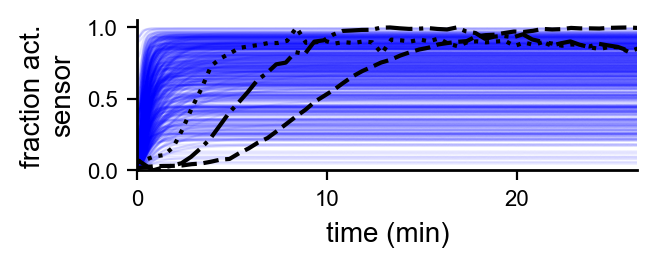

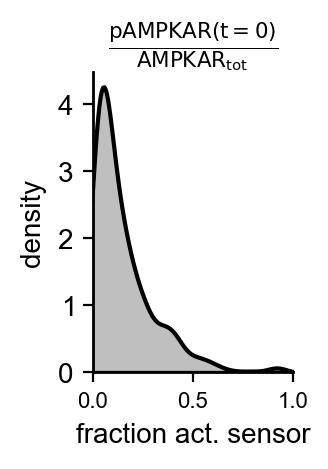

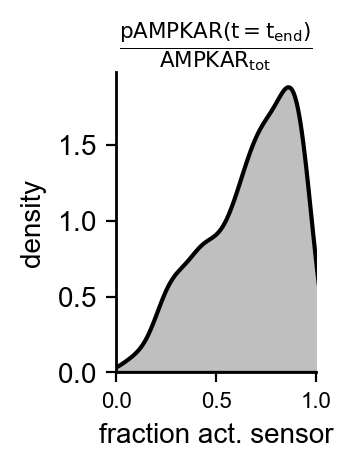

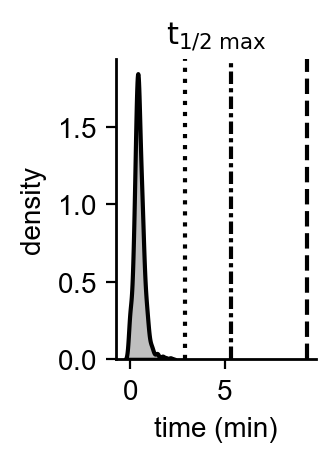

In [7]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MA_default.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MA_default_legend.pdf')
leg.remove()
fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_default.pdf', bbox_inches='tight', transparent=True)
# ax.set_title('MA Single Model - Original Prior predictive')

fig_orig_ma_ratio_basal, ax_orig_ma_ratio_basal = get_sized_fig_ax(1.0, 1.5)
fig_orig_ma_ratio, ax_orig_ma_ratio = get_sized_fig_ax(1.0, 1.5)
fig_orig_ma_t_half_max, ax_orig_ma_t_half_max = get_sized_fig_ax(1.0, 1.5)

axs = [ax_orig_ma_ratio_basal, ax_orig_ma_ratio, ax_orig_ma_t_half_max]
figs= [fig_orig_ma_ratio_basal, fig_orig_ma_ratio, fig_orig_ma_t_half_max]

plot_func_densities(prior_pred_MA_default.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs)


##### Refining the priors

We see that the original prior predictive density does not really capture any of the features we want. We will now tune the priors using **predictive prior elicitation** to achieve a more reasonable prior predictive density.

The code block below, show the predictive elicitation app for the MA single model. We used this app to tune the prior parameters to achieve a reasonable prior predictive density.

In [8]:
# updated_prior_params_MA = {
#     'kOffAMP':    {'mu': -5.5,  'sigma': 1.0},
#     'kOffADP':    {'mu': -5.5,  'sigma': 1.0},
#     'kOffATP':    {'mu': -5.5,  'sigma': 1.0},
#     'kOffCaMKK':  {'mu': -2.75, 'sigma': 1.0},
#     'kPhosCaMKK': {'mu': -3.5,  'sigma': 1.0},
#     'kOffLKB1':   {'mu': 0.0,   'sigma': 1.0},
#     'kPhosLKB1':  {'mu': -3.5,  'sigma': 1.0},
#     'kOffPP':     {'mu': -1.0,  'sigma': 1.0},
#     'kDephosPP':  {'mu': -7.0,  'sigma': 3.0},
#     'kOffAMPK':   {'mu': 0.5,   'sigma': 1.0},
#     'kPhosAMPK':  {'mu': -3.0,  'sigma': 1.0},
#     'kOffPP1':    {'mu': 0.0,   'sigma': 1.0},
#     'kDephosPP1': {'mu': -14.0, 'sigma': 4.0}
#     }

def construct_pm_model_MA_updated(kOffAMP_mu=-5.5,
            kOffAMP_sigma=1.0, 
            kOffADP_mu=-5.5, 
            kOffADP_sigma=1.0, 
            kOffATP_mu=-5.5, 
            kOffATP_sigma=1.0, 
            kOffCaMKK_mu=-2.75, 
            kOffCaMKK_sigma=1.0, 
            kPhosCaMKK_mu=-3.5, 
            kPhosCaMKK_sigma=1.0, 
            kOffLKB1_mu=0.0, 
            kOffLKB1_sigma=1.0, 
            kPhosLKB1_mu=-3.5, 
            kPhosLKB1_sigma=1.0, 
            kOffPP_mu=-1.0, 
            kOffPP_sigma=1.0, 
            kDephosPP_mu=-7.0, 
            kDephosPP_sigma=3.0, 
            kOffAMPK_mu=0.5, 
            kOffAMPK_sigma=1.0, 
            kPhosAMPK_mu=-3.0, 
            kPhosAMPK_sigma=1.0, 
            kOffPP1_mu=0.0, 
            kOffPP1_sigma=1.0, 
            kDephosPP1_mu=-14.0, 
            kDephosPP1_sigma=4.0,
            std_mult=0.001
        ):
    # construct pymc model
    with pm.Model() as model:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=kOffCaMKK_mu, sigma=kOffCaMKK_sigma)
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=kPhosCaMKK_mu, sigma=kPhosCaMKK_sigma)
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=kOffLKB1_mu, sigma=kOffLKB1_sigma)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=kPhosLKB1_mu, sigma=kPhosLKB1_sigma)
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=kOffPP_mu, sigma=kOffPP_sigma)
        kDephosPP = pm.LogNormal('kDephosPP', mu=kDephosPP_mu, sigma=kDephosPP_sigma)
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=kOffAMPK_mu, sigma=kOffAMPK_sigma)
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=kPhosAMPK_mu, sigma=kPhosAMPK_sigma)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=kOffPP1_mu, sigma=kOffPP1_sigma)
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=kDephosPP1_mu, sigma=kDephosPP1_sigma)
        # kDephosPP1 = pm.Data('kDephosPP1', 1e-3)

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK, 
                    kPhosCaMKK, kOnLKB1, kOffLKB1, kPhosLKB1, kOnPP, kOffPP, kDephosPP, 
                    kOnAMPK, kOffAMPK, kPhosAMPK, kOnPP1, kOffPP1, kDephosPP1]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MA(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model

pz.predictive_explorer(construct_pm_model_MA_updated, plot_func=plot_func_trajectories, samples=200)

This looks much better, the trajectories show a range of initial activation rates, followed by a rapid increase in activation, and a steady-state response that fully activates the sensor.

In [9]:
updated_prior_params_MA = {
    'kOffAMP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffADP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffATP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffCaMKK':  {'mu': -2.75, 'sigma': 1.0},
    'kPhosCaMKK': {'mu': -3.5,  'sigma': 1.0},
    'kOffLKB1':   {'mu': 0.0,   'sigma': 1.0},
    'kPhosLKB1':  {'mu': -3.5,  'sigma': 1.0},
    'kOffPP':     {'mu': -1.0,  'sigma': 1.0},
    'kDephosPP':  {'mu': -7.0,  'sigma': 3.0},
    'kOffAMPK':   {'mu': 0.5,   'sigma': 1.0},
    'kPhosAMPK':  {'mu': -3.0,  'sigma': 1.0},
    'kOffPP1':    {'mu': 0.0,   'sigma': 1.0},
    'kDephosPP1': {'mu': -14.0, 'sigma': 4.0}
    }

Let run more samples to get a better sense of the complete prior predictive density.

In [10]:
MA_pm_model_updated = construct_pm_model_MA_updated()

with MA_pm_model_updated:
    prior_pred_MA_updated = pm.sample_prior_predictive(samples=500)

Sampling: [kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


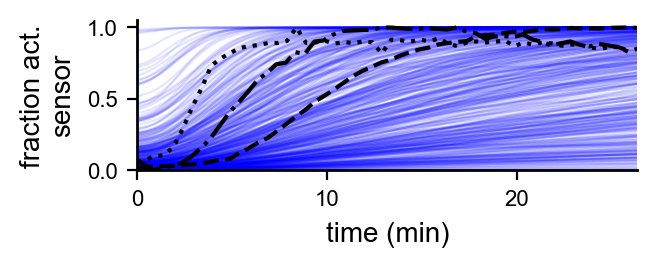

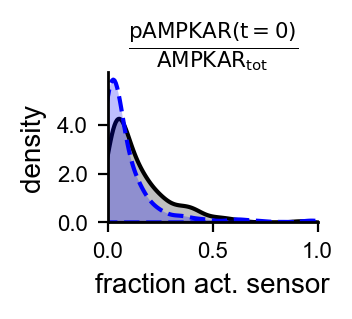

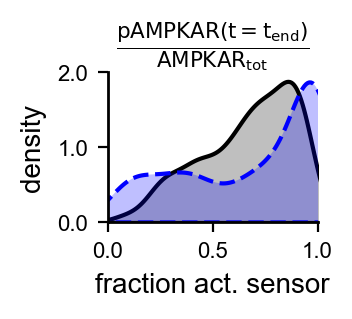

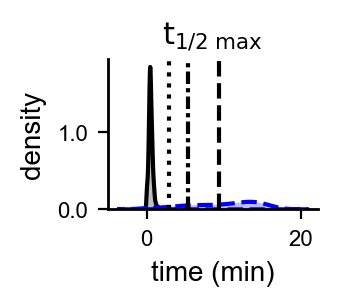

In [11]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MA_updated_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_updated.pdf', bbox_inches='tight', transparent=True)

# fig, ax = plot_func_densities(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:])

fig_orig_ma_ratio_basal, ax_orig_ma_ratio_basal = get_sized_fig_ax(1.05, 0.75)
fig_orig_ma_ratio, ax_orig_ma_ratio = get_sized_fig_ax(1.05, 0.75)
fig_orig_ma_t_half_max, ax_orig_ma_t_half_max = get_sized_fig_ax(1.05, 0.75)

axs = [ax_orig_ma_ratio_basal, ax_orig_ma_ratio, ax_orig_ma_t_half_max]
figs= [fig_orig_ma_ratio_basal, fig_orig_ma_ratio, fig_orig_ma_t_half_max]

plot_func_densities(prior_pred_MA_default.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, plot_data=False)
plot_func_densities(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, linestyle='--', color='b')

# axs[0].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
# axs[1].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
axs[2].legend(['orginal priors', 'refined priors', 'lysosome' , 'mitochondria', 'cytoplasm'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)

leg = axs[2].get_legend()
export_legend(leg, savedir + 'prior_pred_stats_MA_updated_legend.pdf')
leg.remove()

axs[0].set_yticks([0, 2, 4])
axs[0].set_yticklabels(['0.0', '2.0', '4.0'], fontsize=8.0)
axs[1].set_yticks([0, 1, 2])
axs[1].set_yticklabels(['0.0', '1.0', '2.0'], fontsize=8.0)
axs[2].set_yticks([0, 1])
axs[2].set_yticklabels(['0.0', '1.0'], fontsize=8.0)

axs[2].set_xticks([0,20])
axs[2].set_xticklabels(['0', '20'], fontsize=8.0)

# figs[0].tight_layout()
# figs[1].tight_layout()
# figs[2].tight_layout()


figs[0].savefig(savedir + 'prior_pred_MA_updated_ratio_basal.pdf', bbox_inches='tight', transparent=True)
figs[1].savefig(savedir + 'prior_pred_MA_updated_ratio.pdf', bbox_inches='tight', transparent=True)
figs[2].savefig(savedir + 'prior_pred_MA_updated_t_half_max.pdf', bbox_inches='tight', transparent=True)

# axs[2].set_yscale('log')
# axs[2].set_xscale('log')

The initial amount of activated sensor looks much better, but we still see a range of final values. We will use the priors for now, but further refinement could improve them.

We can also compare the 1D marginals from the two sets of priors:

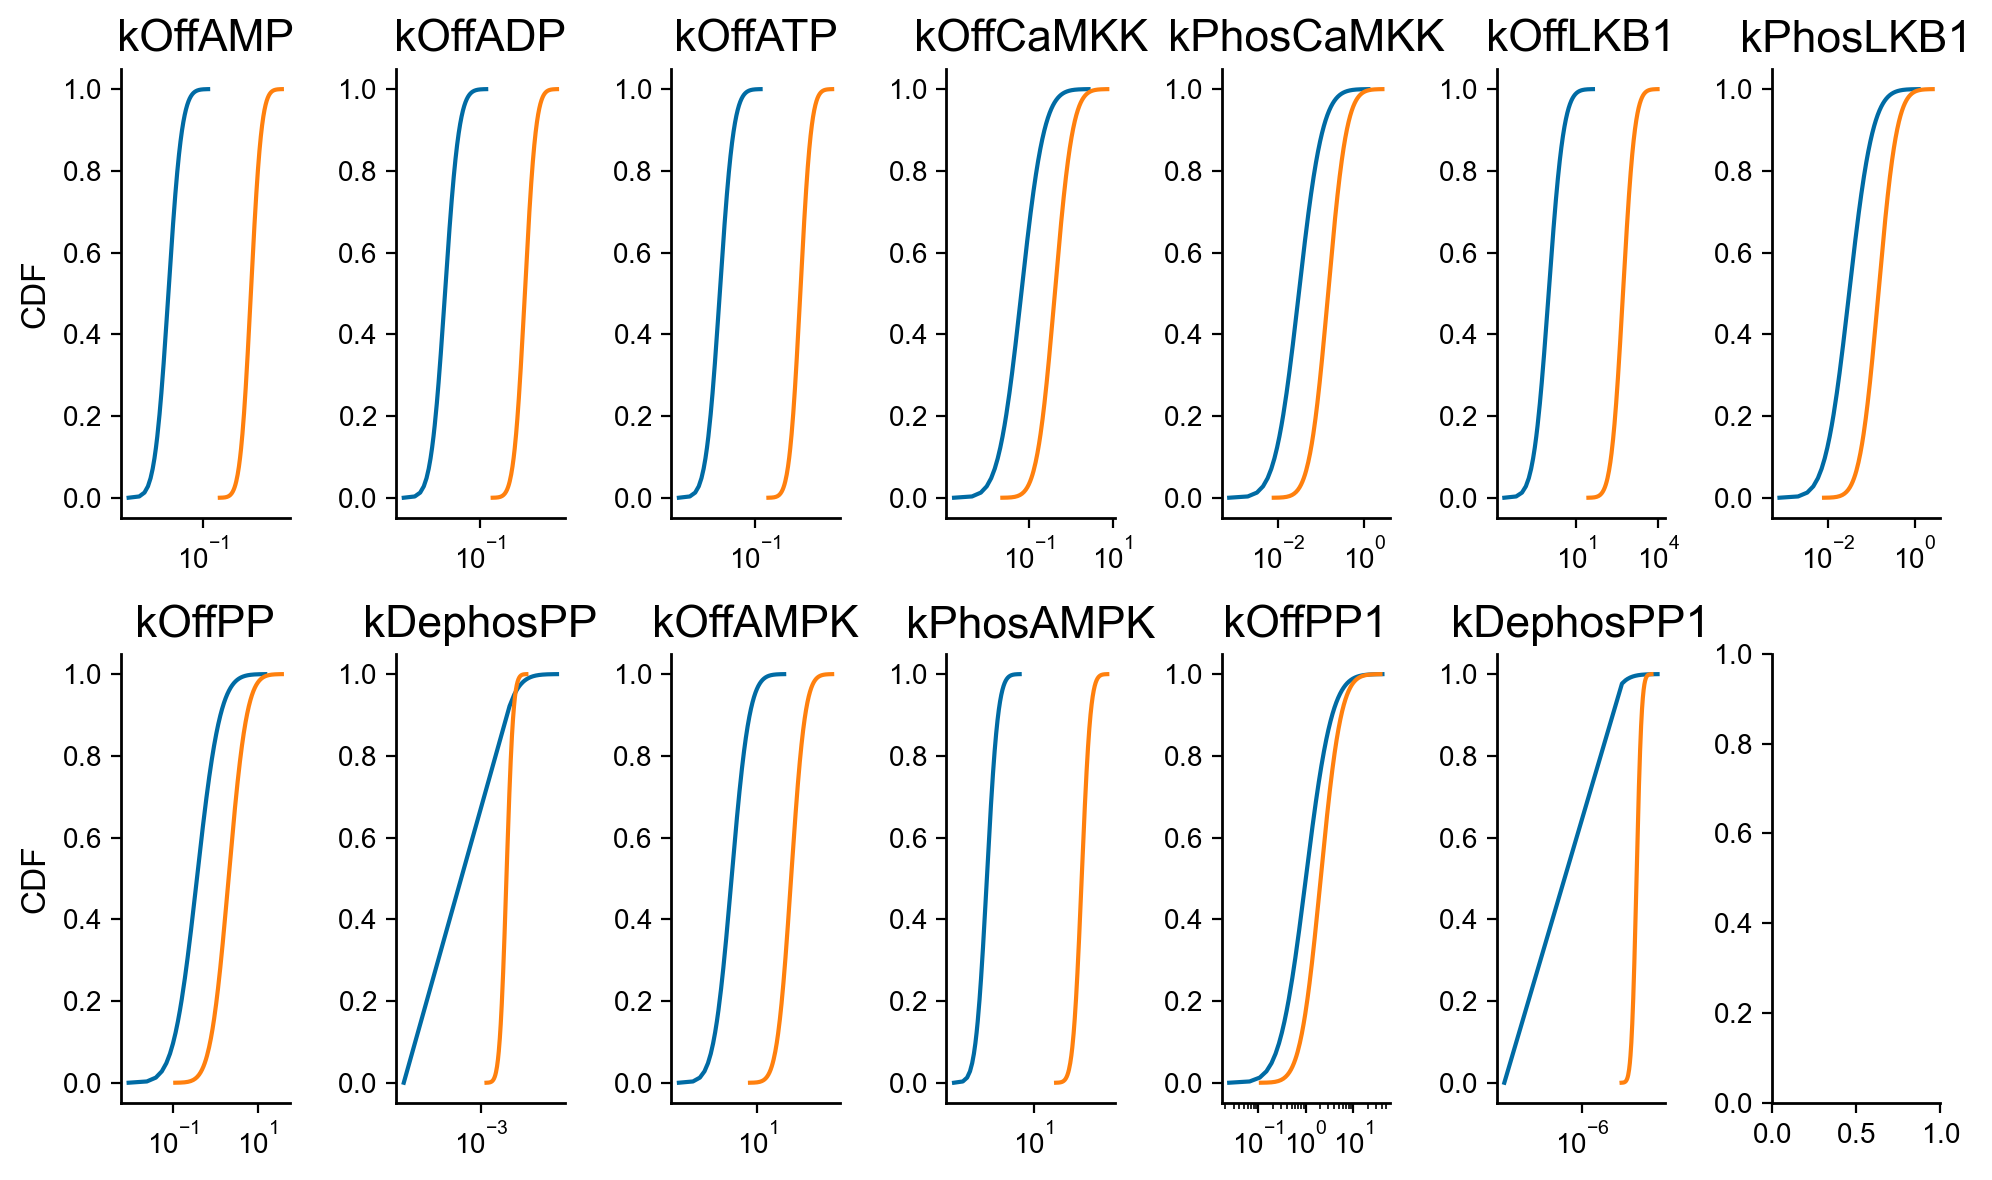

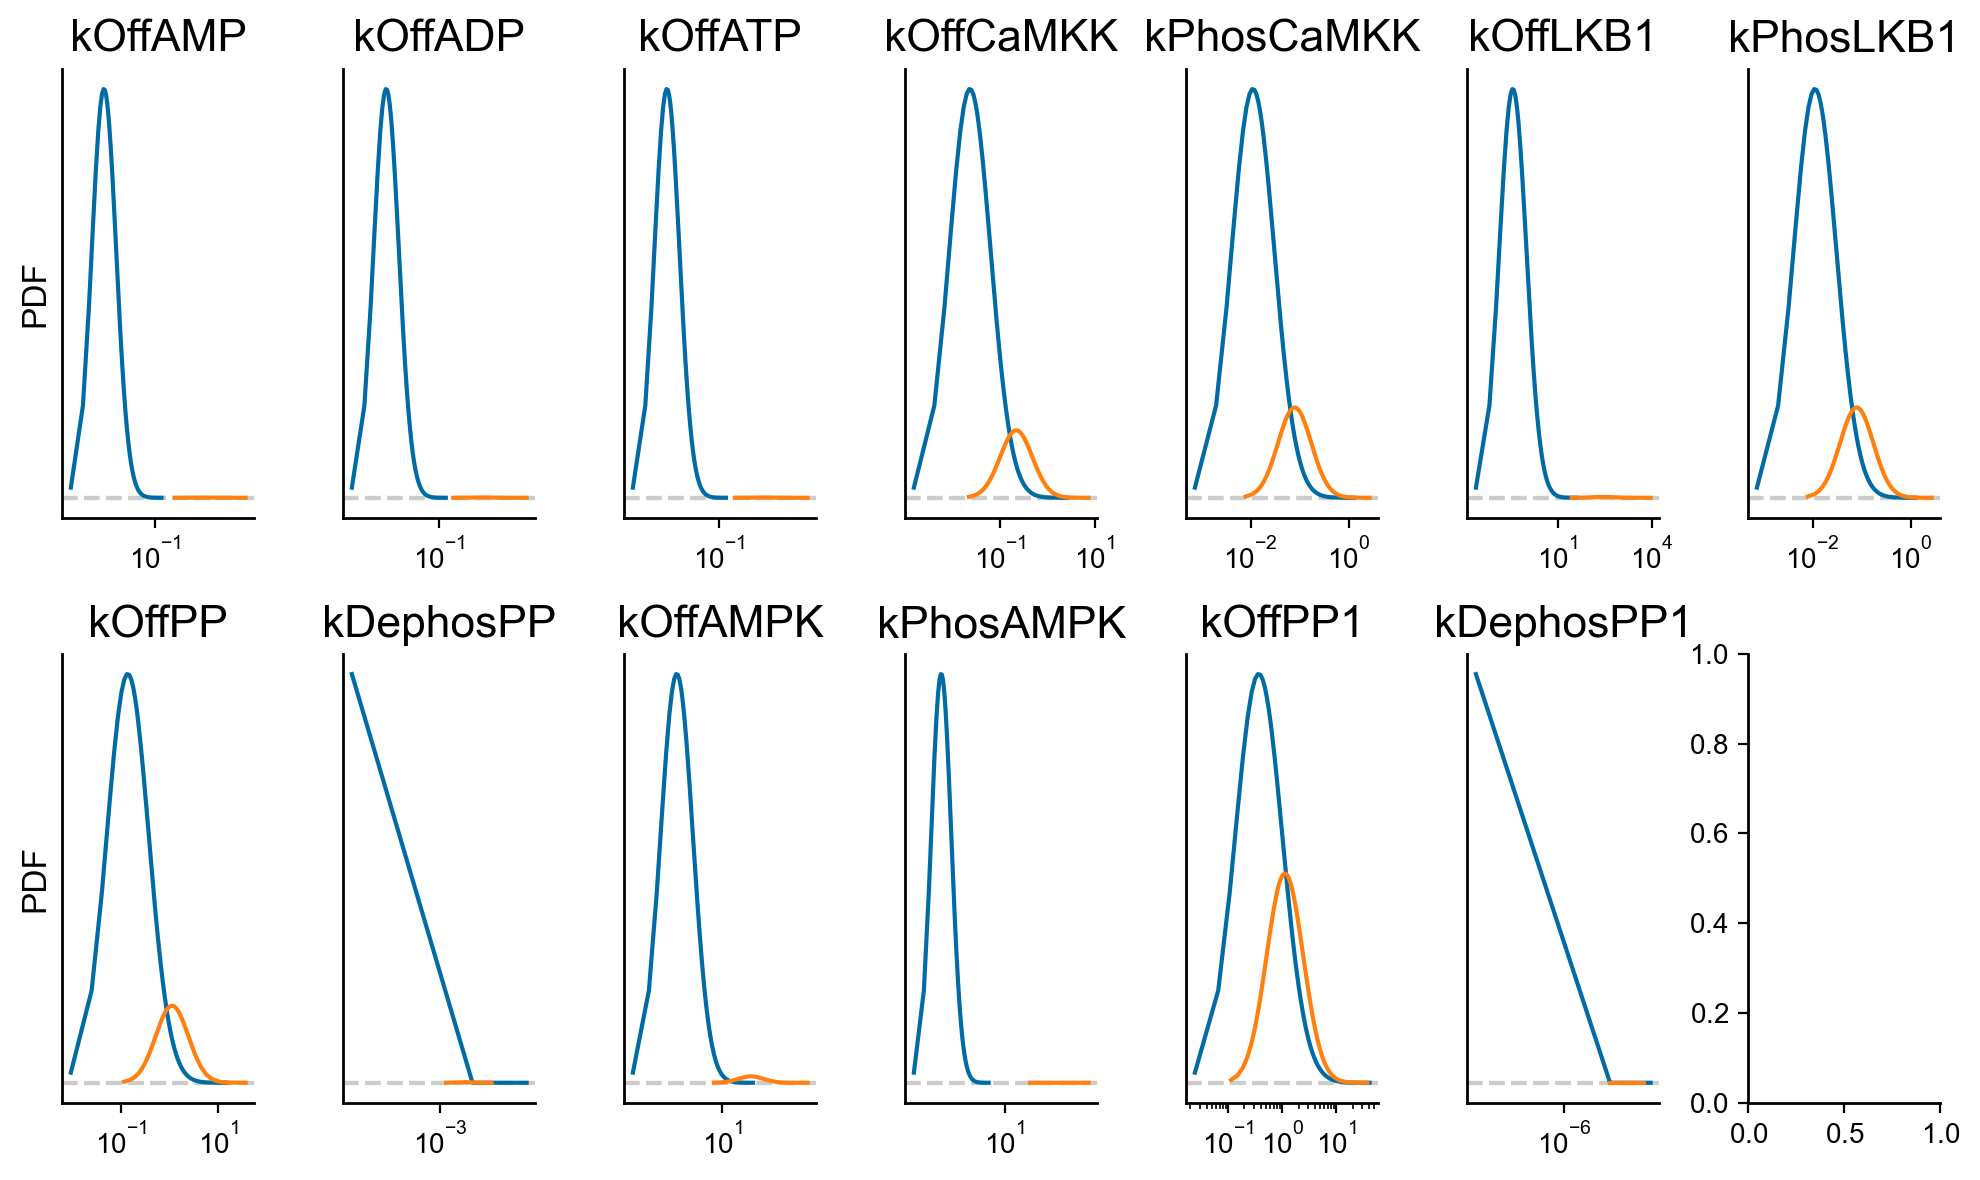

In [15]:
# CDF plot
fig, ax = plt.subplots(2, 7, figsize=(10, 6))
iter = 0
for i in range(2):
    for j in range(7):
        if iter < 13:
            param = list(updated_prior_params_MA.keys())[iter]
            pz.LogNormal(mu=updated_prior_params_MA[param]['mu'], sigma=updated_prior_params_MA[param]['sigma']).plot_cdf(ax=ax[i,j])
            pz.LogNormal(mu=prior_params['MA_single'][param]['mu'], sigma=prior_params['MA_single'][param]['sigma']).plot_cdf(ax=ax[i,j])
            ax[i,j].set_xscale('log')
            # ax[i,j].set_yscale('log')
            ax[i,j].set_title(param, fontweight='normal')
            leg = ax[i,j].get_legend()
            leg.remove()
            iter += 1

ax[0,0].set_ylabel('CDF')
ax[1,0].set_ylabel('CDF')
fig.tight_layout()

# PDF plot
fig, ax = plt.subplots(2, 7, figsize=(10, 6))
iter = 0
for i in range(2):
    for j in range(7):
        if iter < 13:
            param = list(updated_prior_params_MA.keys())[iter]
            pz.LogNormal(mu=updated_prior_params_MA[param]['mu'], sigma=updated_prior_params_MA[param]['sigma']).plot_pdf(ax=ax[i,j])
            pz.LogNormal(mu=prior_params['MA_single'][param]['mu'], sigma=prior_params['MA_single'][param]['sigma']).plot_pdf(ax=ax[i,j])
            ax[i,j].set_xscale('log')
            # ax[i,j].set_yscale('log')
            ax[i,j].set_title(param, fontweight='normal')
            leg = ax[i,j].get_legend()
            leg.remove()
            iter += 1

ax[0,0].set_ylabel('PDF')
ax[1,0].set_ylabel('PDF')
fig.tight_layout()


Finally lets update the bounds in the model_info files to reflect the new priors. These will be used for generating samples for GSA. We will use the 95% highest posterior density interval as the bounds.

We will also store the new prior parameters in the model_info files

In [16]:
#  95% hdi of updated prior for bounds for GSA
MA_bounds_updated = {}
MA_prior_params_updated = {}
for param in MA_info['params']:
    if param in updated_prior_params_MA.keys():
        # hdi
        bounds = list(pz.LogNormal(mu=updated_prior_params_MA[param]['mu'], sigma=updated_prior_params_MA[param]['sigma']).hdi(0.95, fmt='.8f'))
        MA_bounds_updated[param] = bounds

        # prior params
        MA_prior_params_updated[param] = updated_prior_params_MA[param]
    else:
        MA_bounds_updated[param] = []
        MA_prior_params_updated[param] = {}

# update the model info file with the new bounds
MA_info['param_bounds'] =  MA_bounds_updated
MA_info['prior_params'] = MA_prior_params_updated

# save the updated model info
with open('../models/MA_single.json', 'w') as file:
    json.dump(MA_info, file, indent=4)

## Predictive elicitation for the MM model

In [17]:
# sample from prior predictive with original priors
with MM_pm_model_default:
    prior_pred_MM_default = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


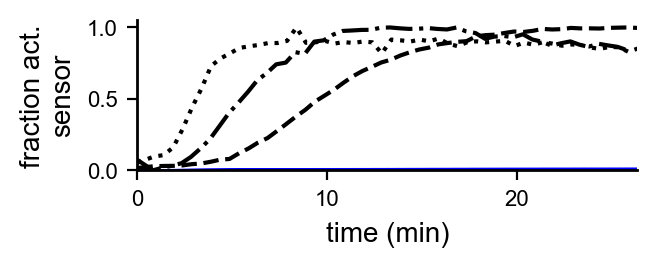

In [18]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MM_default.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
leg.remove()

fig.savefig(savedir + 'prior_pred_MM_default.pdf', bbox_inches='tight', transparent=True)



# fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# plot_func_trajectories(prior_pred_MM_default.prior_predictive['like'].values[0,:,:,:], ax)
# ax.set_title('MM Single Model - Original Prior predictive')

# fig, ax = plot_func_densities(prior_pred_MM_default.prior_predictive['like'].values[0,:,:,:])

The above prior predictive densities show that with the current priors and nominals values, the MM model cannot predict ANY sensor activation. This is likely because the nominal values for the dephosporylation of the sensor and the phosphorylation of the sensor are incorrect. However, these parameters are not locally identifiable, so we do not want to simply add them as free params.

There are two options for choosing new nominal values for the dephosphorylation and phosphorylation rates of the sensor:

1. Use the mean of the MA model, to calculate new nominal params
2. Compute prior predictive densities with varying values of the dephosphorylation and phosphorylation rates of the sensor and choose values that give reasonable prior predictive densities.

We will begin with option number 2, and then if that fails we will try option number 1.

In [32]:
# vary only kAMPK
kAMPKs = [1.92e-5, 1.92e-4, 1.92e-3, 1.92e-2, 1.92e-1, 1.92e0, 1.92e1, 1.92e2]
preds_kAMPK_vary = []

for kAMPK in kAMPKs:
    MM_pm_model_updated = construct_pm_model_MM(kAMPK=kAMPK)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=10)
    preds_kAMPK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only KmAMPK
KmAMPKs = [8.49e-3, 8.49e-2, 8.49e-1, 8.49e0, 8.49e1, 8.49e2, 8.49e3]
preds_KmAMPK_vary = []

for KmAMPK in KmAMPKs:
    MM_pm_model_updated = construct_pm_model_MM(KmAMPK=KmAMPK)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=10)
    preds_KmAMPK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only kPP1
kPP1s = [1.1e-6, 1.1e-5, 1.1e-4, 1.1e-3, 1.1e-2, 1.1e-1, 1.1e0, 1.1e1]
preds_kPP1_vary = []

for kPP1 in kPP1s:
    MM_pm_model_updated = construct_pm_model_MM(kPP1=kPP1)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=10)
    preds_kPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only KmPP1
KmPP1s = [6.7e-4, 6.7e-3, 6.7e-2, 6.7e-1, 6.7e0, 6.7e1, 6.7e2]
preds_KmPP1_vary = []
for KmPP1 in KmPP1s:
    MM_pm_model_updated = construct_pm_model_MM(KmPP1=KmPP1)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=10)
    preds_KmPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, k

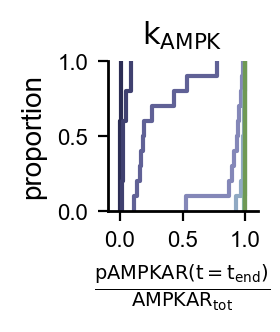

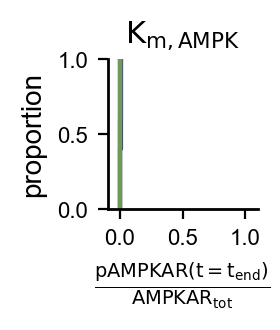

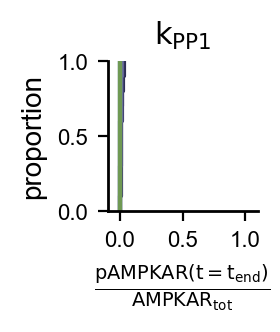

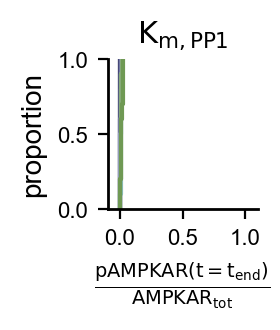

In [33]:
# plot histograms of pAMPKAR(t=tend)/AMPKAR_tot for the four varying parameters
fig, ax = get_sized_fig_ax(0.75,0.75)
fig1, ax1 = get_sized_fig_ax(0.75,0.75)
fig2, ax2 = get_sized_fig_ax(0.75,0.75)
fig3, ax3 = get_sized_fig_ax(0.75,0.75)

ax.set_title(r'$k_{AMPK}$', fontweight='regular', fontsize=11.0)
ax1.set_title(r'$K_{m,AMPK}$', fontweight='regular', fontsize=11.0)
ax2.set_title(r'$k_{PP1}$', fontweight='regular', fontsize=11.0)
ax3.set_title(r'$K_{m,PP1}$', fontweight='regular', fontsize=11.0)

# kAMPK
for i in range(len(kAMPKs)):
    color = mb.met_brew(name="VanGogh1", n=len(kAMPKs), brew_type='continuous')[i]
    if kAMPKs[i] == 1.92e-5:
        label = f'{kAMPKs[i]}*'
    else:
        label=f'{kAMPKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kAMPK_vary[i][:,0,-1]), ax=ax, color=color, label=label)

# KmAMPK
for i in range(len(KmAMPKs)):
    color = mb.met_brew(name="VanGogh1", n=len(KmAMPKs), brew_type='continuous')[i]
    if KmAMPKs[i] == 8.49e-2:
        label = f'{KmAMPKs[i]}*'
    else:
        label=f'{KmAMPKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmAMPK_vary[i][:,0,-1]), ax=ax1, color=color, label=label)

# kPP1
for i in range(len(kPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(kPP1s), brew_type='continuous')[i]
    if kPP1s[i] == 1.1e-4:
        label = f'{kPP1s[i]}*'
    else:
        label=f'{kPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kPP1_vary[i][:,0,-1]), ax=ax2, color=color, label=label)

# KmPP1
for i in range(len(KmPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(KmPP1s), brew_type='continuous')[i]
    if KmPP1s[i] == 6.7e-2:
        label = f'{KmPP1s[i]}*'
    else:
        label=f'{KmPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmPP1_vary[i][:,0,-1]), ax=ax3, color=color, label=label)

ax.legend(title=r'$k_{AMPK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax1.legend(title=r'$K_{m,AMPK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax2.legend(title=r'$k_{PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax3.legend(title=r'$K_{m,PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)

ax.set_xlim([-0.1,1.1])
ax1.set_xlim([-0.1,1.1])
ax2.set_xlim([-0.1,1.1])
ax3.set_xlim([-0.1,1.1])

ax.set_ylabel('proportion', fontsize=10.0)
ax1.set_ylabel('proportion', fontsize=10.0)
ax2.set_ylabel('proportion', fontsize=10.0)
ax3.set_ylabel('proportion', fontsize=10.0)

ax.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax1.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax2.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax3.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)

ax.set_xticks([0, 0.5, 1.0])
ax1.set_xticks([0, 0.5, 1.0])
ax2.set_xticks([0, 0.5, 1.0])
ax3.set_xticks([0, 0.5, 1.0])
ax.set_yticks([0, 0.5, 1.0])
ax1.set_yticks([0, 0.5, 1.0])
ax2.set_yticks([0, 0.5, 1.0])
ax3.set_yticks([0, 0.5, 1.0])

ax.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax3.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax3.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_kAMPK_legend.pdf')
leg.remove()

leg = ax1.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_KmAMPK_legend.pdf')
leg.remove()

leg = ax2.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_kPP1_legend.pdf')
leg.remove()

leg = ax3.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_KmPP1_legend.pdf')
leg.remove()

fig.savefig(savedir + 'prior_pred_MM_var_kAMPK.pdf', bbox_inches='tight', transparent=True)
fig1.savefig(savedir + 'prior_pred_MM_var_KmAMPK.pdf', bbox_inches='tight', transparent=True)
fig2.savefig(savedir + 'prior_pred_MM_var_kPP1.pdf', bbox_inches='tight', transparent=True)
fig3.savefig(savedir + 'prior_pred_MM_var_KmPP1.pdf', bbox_inches='tight', transparent=True)

kAMPK makes a big difference. Choose kAMPK = 1.92e-3 and repeat for other parameters.

In [34]:
# vary only KmAMPK
KmAMPKs = [8.49e-3, 8.49e-2, 8.49e-1, 8.49e0, 8.49e1, 8.49e2, 8.49e3]
preds_KmAMPK_vary = []

for KmAMPK in KmAMPKs:
    MM_pm_model_updated = construct_pm_model_MM(KmAMPK=KmAMPK, kAMPK=1.92e-3)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=10)
    preds_KmAMPK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only kPP1
kPP1s = [1.1e-6, 1.1e-5, 1.1e-4, 1.1e-3, 1.1e-2, 1.1e-1, 1.1e0, 1.1e1]
preds_kPP1_vary = []

for kPP1 in kPP1s:
    MM_pm_model_updated = construct_pm_model_MM(kPP1=kPP1, kAMPK=1.92e-3)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=10)
    preds_kPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only KmPP1
KmPP1s = [6.7e-4, 6.7e-3, 6.7e-2, 6.7e-1, 6.7e0, 6.7e1, 6.7e2]
preds_KmPP1_vary = []
for KmPP1 in KmPP1s:
    MM_pm_model_updated = construct_pm_model_MM(KmPP1=KmPP1, kAMPK=1.92e-3)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=10)
    preds_KmPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, k

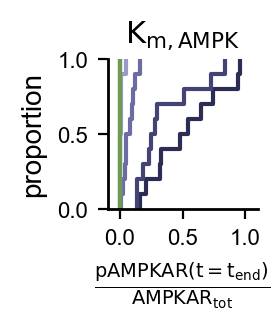

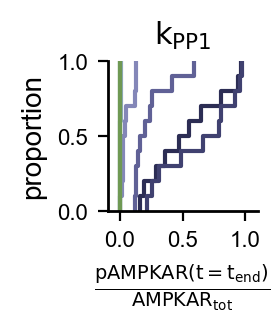

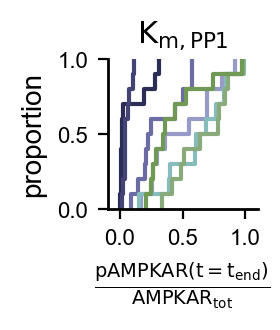

In [35]:
# plot histograms of pAMPKAR(t=tend)/AMPKAR_tot for the four varying parameters
fig, ax = get_sized_fig_ax(0.75,0.75)
fig1, ax1 = get_sized_fig_ax(0.75,0.75)
fig2, ax2 = get_sized_fig_ax(0.75,0.75)

ax.set_title(r'$K_{m,AMPK}$', fontweight='regular', fontsize=11.0)
ax1.set_title(r'$k_{PP1}$', fontweight='regular', fontsize=11.0)
ax2.set_title(r'$K_{m,PP1}$', fontweight='regular', fontsize=11.0)

# KmAMPK
for i in range(len(KmAMPKs)):
    color = mb.met_brew(name="VanGogh1", n=len(KmAMPKs), brew_type='continuous')[i]
    if KmAMPKs[i] == 8.49e-2:
        label = f'{KmAMPKs[i]}*'
    else:
        label=f'{KmAMPKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmAMPK_vary[i][:,0,-1]), ax=ax, color=color, label=label)

# kPP1
for i in range(len(kPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(kPP1s), brew_type='continuous')[i]
    if kPP1s[i] == 1.1e-4:
        label = f'{kPP1s[i]}*'
    else:
        label=f'{kPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kPP1_vary[i][:,0,-1]), ax=ax1, color=color, label=label)

# KmPP1
for i in range(len(KmPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(KmPP1s), brew_type='continuous')[i]
    if KmPP1s[i] == 6.7e-2:
        label = f'{KmPP1s[i]}*'
    else:
        label=f'{KmPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmPP1_vary[i][:,0,-1]), ax=ax2, color=color, label=label)


ax.legend(title=r'$K_{m,AMPK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax1.legend(title=r'$k_{PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax2.legend(title=r'$K_{m,PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)

ax.set_xlim([-0.1,1.1])
ax1.set_xlim([-0.1,1.1])
ax2.set_xlim([-0.1,1.1])

ax.set_ylabel('proportion', fontsize=10.0)
ax1.set_ylabel('proportion', fontsize=10.0)
ax2.set_ylabel('proportion', fontsize=10.0)

ax.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax1.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax2.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)

ax.set_xticks([0, 0.5, 1.0])
ax1.set_xticks([0, 0.5, 1.0])
ax2.set_xticks([0, 0.5, 1.0])
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticks([0, 0.5, 1.0])
ax1.set_yticks([0, 0.5, 1.0])
ax2.set_yticks([0, 0.5, 1.0])

ax.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)


leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_fix_kAMPK_var_KmAMPK_legend.pdf')
leg.remove()

leg = ax1.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_fix_kAMPK_var_kPP1_legend.pdf')
leg.remove()

leg = ax2.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_fix_kAMPK_var_KmPP1_legend.pdf')
leg.remove()

fig.savefig(savedir + 'prior_pred_MM_fix_kAMPK_var_KmAMPK.pdf', bbox_inches='tight', transparent=True)
fig1.savefig(savedir + 'prior_pred_MM_fix_kAMPK_var_kPP1.pdf', bbox_inches='tight', transparent=True)
fig2.savefig(savedir + 'prior_pred_MM_fix_kAMPK_var_KmPP1.pdf', bbox_inches='tight', transparent=True)

Choose KmAMPK = 8.5e-3 and leave the other parameters the same.

Now redraw prior predictive densities

Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


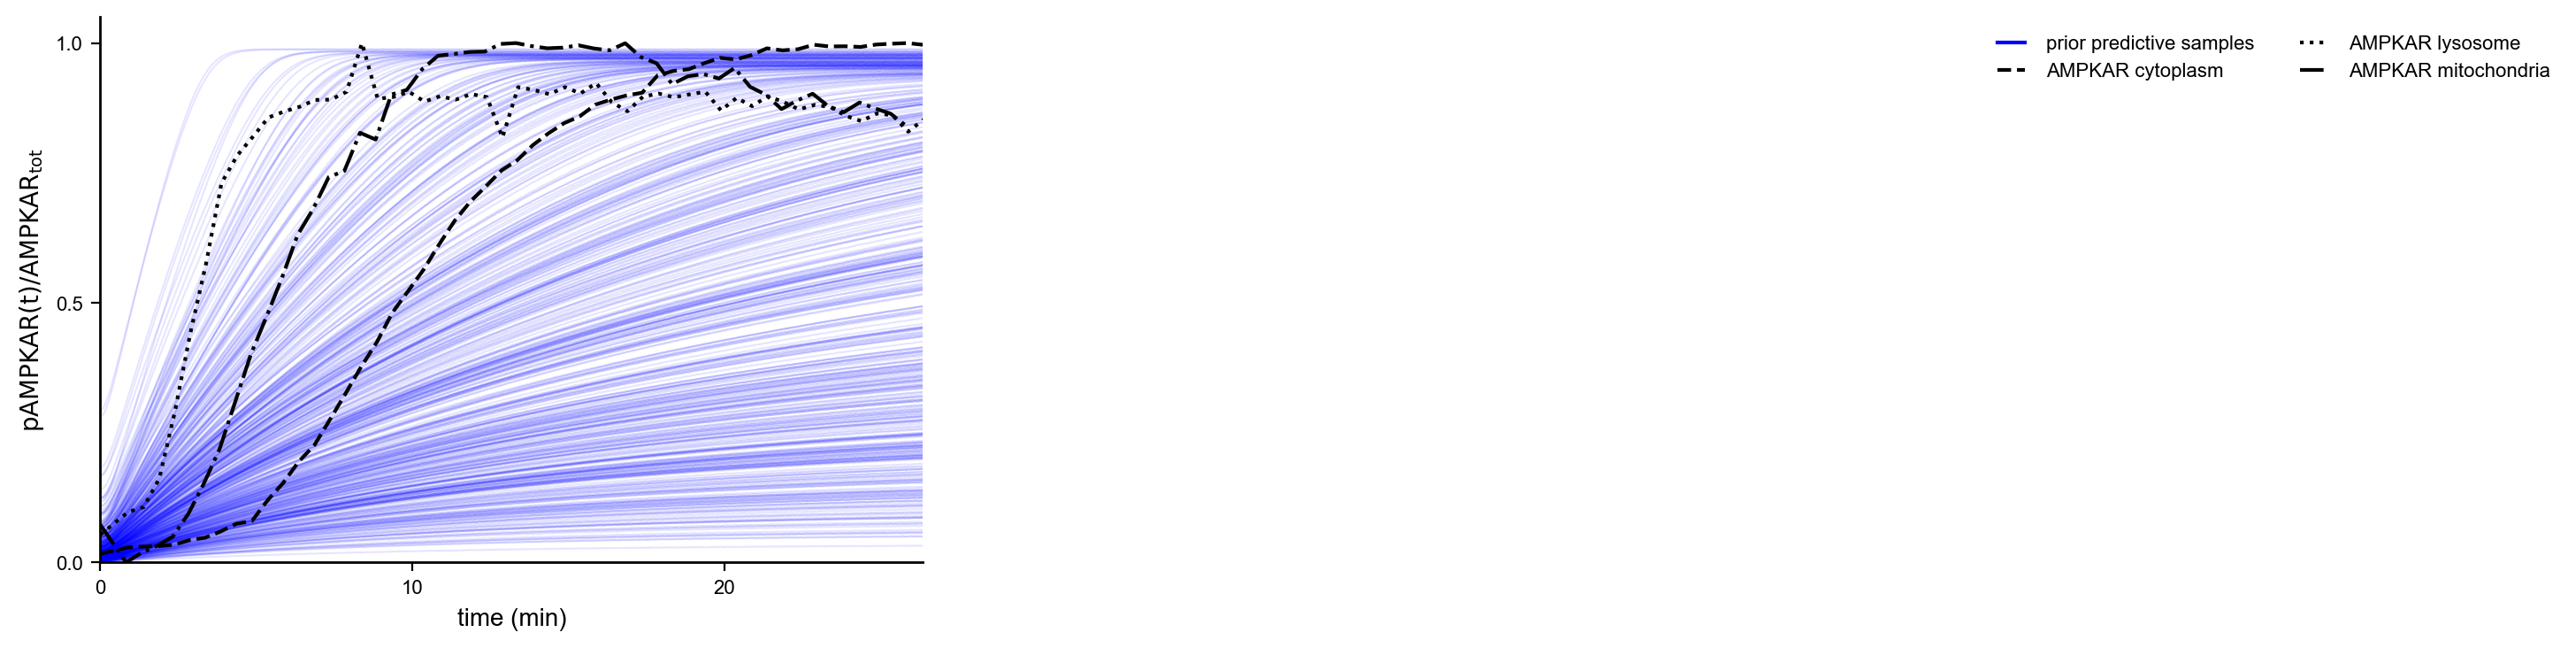

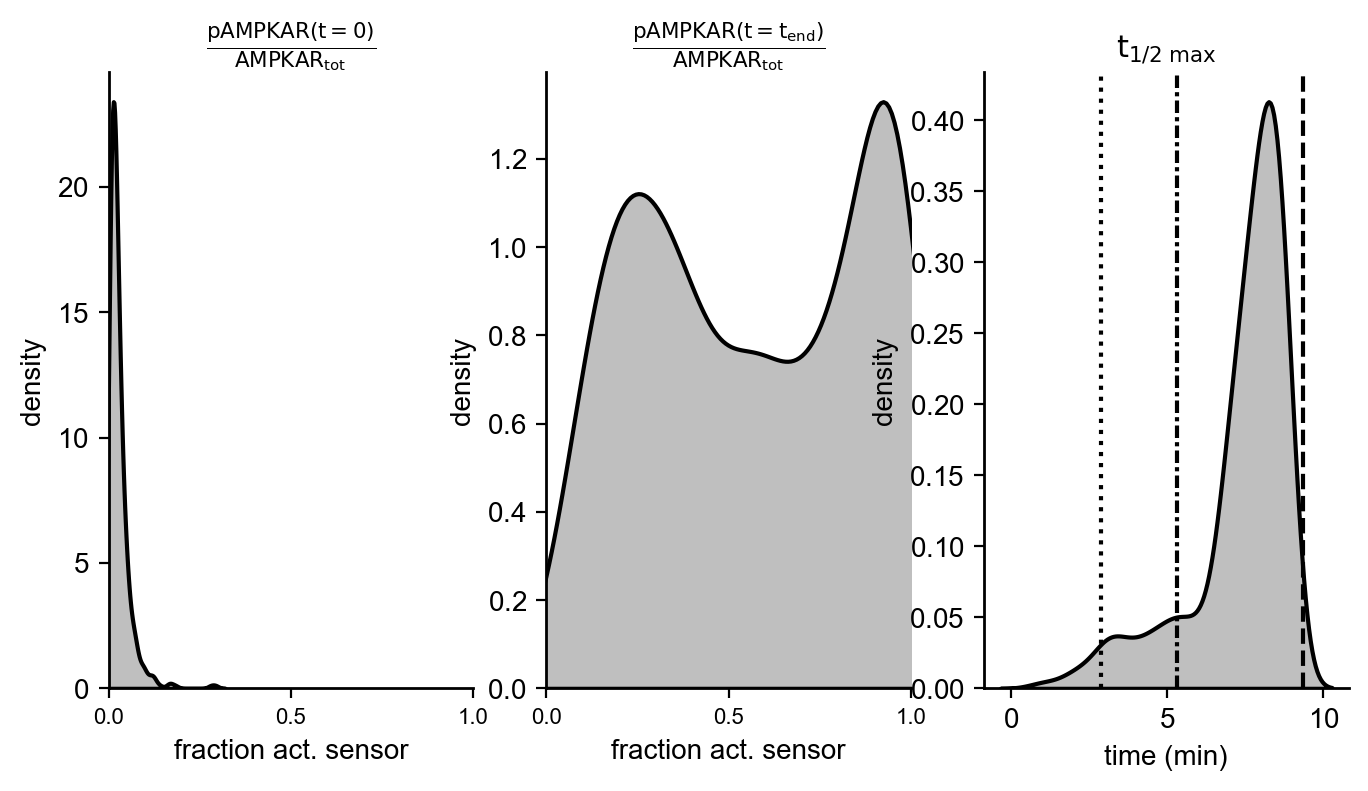

In [38]:
MM_pm_model_updated = construct_pm_model_MM(KmAMPK=8.5e-3, kAMPK=1.92e-3)
with MM_pm_model_updated:
    prior_pred_MM_updated = pm.sample_prior_predictive(samples=500)


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_func_trajectories(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:], ax)

plot_func_densities(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

This look decent, however the initial "slow-phase" is a bit short... lets try refining the priors...

In [39]:
def construct_pm_model_MM_updated(kOffAMP_mu=MM_info['prior_params']['kOffAMP']['mu'],
            kOffAMP_sigma=MM_info['prior_params']['kOffAMP']['sigma'],
            kOffADP_mu=MM_info['prior_params']['kOffADP']['mu'],
            kOffADP_sigma=MM_info['prior_params']['kOffADP']['sigma'],
            kOffATP_mu=MM_info['prior_params']['kOffATP']['mu'],
            kOffATP_sigma=MM_info['prior_params']['kOffATP']['sigma'],
            kCaMKK_mu=MM_info['prior_params']['kCaMKK']['mu'],
            kCaMKK_sigma=MM_info['prior_params']['kCaMKK']['sigma'],
            Km_CaMKK_mu=MM_info['prior_params']['KmCaMKK']['mu'],
            Km_CaMKK_sigma=MM_info['prior_params']['KmCaMKK']['sigma'],
            kLKB1_mu=MM_info['prior_params']['kLKB1']['mu'],
            kLKB1_sigma=MM_info['prior_params']['kLKB1']['sigma'],
            KmLKB1_mu=MM_info['prior_params']['KmLKB1']['mu'],
            KmLKB1_sigma=MM_info['prior_params']['KmLKB1']['sigma'],
            kPP_mu=MM_info['prior_params']['kPP']['mu'],
            kPP_sigma=MM_info['prior_params']['kPP']['sigma'],
            KmPP_mu=MM_info['prior_params']['KmPP']['mu'],
            KmPP_sigma=MM_info['prior_params']['KmPP']['sigma'],
            std_mult=0.001
            ):
    # construct pymc model
    with pm.Model() as model_MM:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0) 
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kCaMKK = pm.LogNormal('kCaMKK', mu=kCaMKK_mu, sigma=kCaMKK_sigma)
        KmCaMKK = pm.LogNormal('KmCaMKK', mu=Km_CaMKK_mu, sigma=Km_CaMKK_sigma)
        kLKB1 = pm.LogNormal('kLKB1', mu=kLKB1_mu, sigma=kLKB1_sigma)
        KmLKB1 = pm.LogNormal('KmLKB1', mu=KmLKB1_mu, sigma=KmLKB1_sigma)
        kPP = pm.LogNormal('kPP', mu=kPP_mu, sigma=kPP_sigma)
        KmPP = pm.LogNormal('KmPP', mu=KmPP_mu, sigma=KmPP_sigma)
        kAMPK = pm.Data('pAMPK',1.92e-3)
        KmAPK = pm.Data('KmAMPK', 8.5e-3)
        kPP1 = pm.Data('pPP1', MM_info['nominal_params']['kPP1'])
        KmPP1 = pm.Data('KmPP1', MM_info['nominal_params']['KmPP1'])
        CaMKKtot = pm.Data('CaMKKtot', 1.0)
        LKB1tot = pm.Data('LKB1tot', 1.0)
        PPtot = pm.Data('PPtot', 1.0)
        PP1tot = pm.Data('PP1tot', 1.0)

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, 
                  kCaMKK, KmCaMKK, kLKB1, KmLKB1, kPP, KmPP, 
                  kAMPK, KmAPK, kPP1, KmPP1, CaMKKtot, LKB1tot, PPtot, PP1tot]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MM(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model_MM

pz.predictive_explorer(construct_pm_model_MM_updated, plot_func=plot_func_trajectories, samples=200)

This looks much better. The main changes were to change the AXP off rate priors to match those of the MA model. We additionally rounded the other prior parameters to nearest 1, 0.5 or .25 and set all standard deviations to 1.0.

In [41]:
updated_prior_params_MM = {
    'kOffAMP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffADP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffATP':    {'mu': -5.5,  'sigma': 1.0},
    'kCaMKK':     {'mu': -2.0, 'sigma': 1.0},
    'KmCaMKK':    {'mu': -0.5,  'sigma': 1.0},
    'kLKB1':      {'mu': -2.0,   'sigma': 1.0},
    'KmLKB1':     {'mu': 6,  'sigma': 1.0},
    'kPP':        {'mu': -3.0,  'sigma': 1.0},
    'KmPP':       {'mu': 0.75,  'sigma': 3.0}
}

MM_pm_model_updated = construct_pm_model_MM_updated(
    kOffAMP_mu=updated_prior_params_MM['kOffAMP']['mu'],
    kOffAMP_sigma=updated_prior_params_MM['kOffAMP']['sigma'],
    kOffADP_mu=updated_prior_params_MM['kOffADP']['mu'],
    kOffADP_sigma=updated_prior_params_MM['kOffADP']['sigma'],
    kOffATP_mu=updated_prior_params_MM['kOffATP']['mu'],
    kOffATP_sigma=updated_prior_params_MM['kOffATP']['sigma'],
    kCaMKK_mu=updated_prior_params_MM['kCaMKK']['mu'],
    kCaMKK_sigma=updated_prior_params_MM['kCaMKK']['sigma'],
    Km_CaMKK_mu=updated_prior_params_MM['KmCaMKK']['mu'],
    Km_CaMKK_sigma=updated_prior_params_MM['KmCaMKK']['sigma'],
    kLKB1_mu=updated_prior_params_MM['kLKB1']['mu'],
    kLKB1_sigma=updated_prior_params_MM['kLKB1']['sigma'],
    KmLKB1_mu=updated_prior_params_MM['KmLKB1']['mu'],
    KmLKB1_sigma=updated_prior_params_MM['KmLKB1']['sigma'],
    kPP_mu=updated_prior_params_MM['kPP']['mu'],
    kPP_sigma=updated_prior_params_MM['kPP']['sigma'],
    std_mult=0.001)

with MM_pm_model_updated:
    prior_pred_MM_updated = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


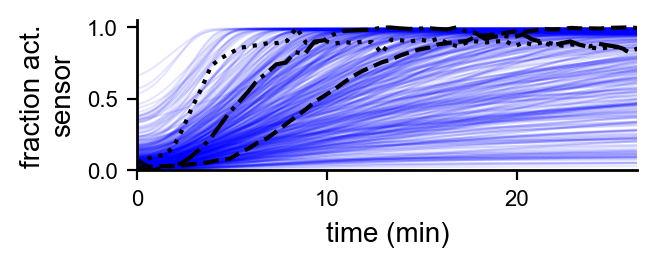

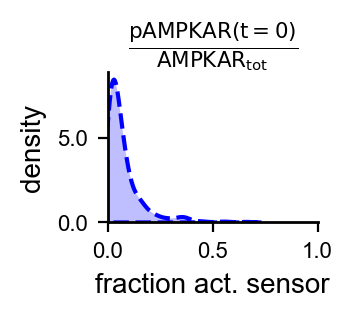

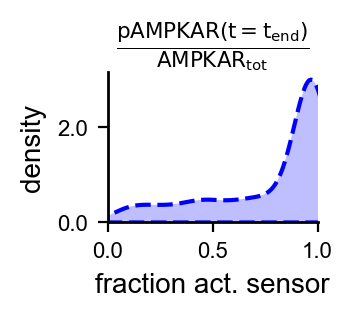

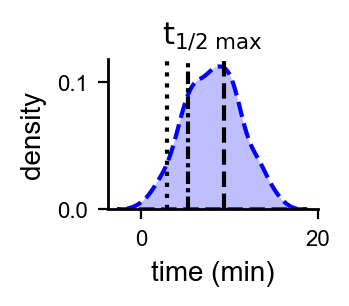

In [48]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_updated_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MM_updated.pdf', bbox_inches='tight', transparent=True)

fig_orig_mm_ratio_basal, ax_orig_mm_ratio_basal = get_sized_fig_ax(1.05, 0.75)
fig_orig_mm_ratio, ax_orig_mm_ratio = get_sized_fig_ax(1.05, 0.75)
fig_orig_mm_t_half_max, ax_orig_mm_t_half_max = get_sized_fig_ax(1.05, 0.75)

axs = [ax_orig_mm_ratio_basal, ax_orig_mm_ratio, ax_orig_mm_t_half_max]
figs= [fig_orig_mm_ratio_basal, fig_orig_mm_ratio, fig_orig_mm_t_half_max]

# plot_func_densities(prior_pred_MM_default.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, plot_data=False)
plot_func_densities(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, linestyle='--', color='b')

# axs[0].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
# axs[1].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
axs[2].legend(['refined priors', 'lysosome' , 'mitochondria', 'cytoplasm'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)

leg = axs[2].get_legend()
export_legend(leg, savedir + 'prior_pred_stats_MM_updated_legend.pdf')
leg.remove()

axs[0].set_yticks([0, 5])
axs[0].set_yticklabels(['0.0', '5.0'], fontsize=8.0)
axs[1].set_yticks([0, 2])
axs[1].set_yticklabels(['0.0', '2.0'], fontsize=8.0)
axs[2].set_yticks([0, 0.1])
axs[2].set_yticklabels(['0.0', '0.1'], fontsize=8.0)

axs[2].set_xticks([0,20])
axs[2].set_xticklabels(['0', '20'], fontsize=8.0)


figs[0].savefig(savedir + 'prior_pred_MM_updated_ratio_basal.pdf', bbox_inches='tight', transparent=True)
figs[1].savefig(savedir + 'prior_pred_MM_updated_ratio.pdf', bbox_inches='tight', transparent=True)
figs[2].savefig(savedir + 'prior_pred_MM_updated_t_half_max.pdf', bbox_inches='tight', transparent=True)

This looks pretty good. Lets store these priors in the model_info file and compute the HDI as we did for the MA model

In [17]:
#  95% hdi of updated prior for bounds for GSA
MM_bounds_updated = {}
MM_prior_params_updated = {}
for param in MM_info['params']:
    if param in updated_prior_params_MM.keys():
        # hdi
        bounds = list(pz.LogNormal(mu=updated_prior_params_MM[param]['mu'], sigma=updated_prior_params_MM[param]['sigma']).hdi(0.95, fmt='.8f'))
        MM_bounds_updated[param] = bounds

        # prior params
        MM_prior_params_updated[param] = updated_prior_params_MM[param]
    else:
        MM_bounds_updated[param] = []
        MM_prior_params_updated[param] = {}

# update the model info file with the new bounds
MM_info['param_bounds'] =  MM_bounds_updated
MM_info['prior_params'] = MM_prior_params_updated

# save the updated model info
with open('../models/MM_single.json', 'w') as file:
    json.dump(MM_info, file, indent=4)

## Other models

Now for the other three models.

For `MA_nonessential` and `MM_nonessential`, we will use the priors from the `MA` and `MM` models, respectively. We will use the original bounds and prior parameters for the $\alpha$ and $\beta$ parameters.

Double check that the prior predictive densities look reasonable

In [6]:
from MA_nonessential_diffrax import *
from MM_nonessential_diffrax import *

MA_non_info = json.load(open('../models/MA_nonessential.json'))
MM_non_info = json.load(open('../models/MM_nonessential.json'))

# get initial conditions
y0_MA_non = list(MA_non_info['init_conds'].values())
y0_MM_non = list(MM_non_info['init_conds'].values())

# deal with getting AMPKAR idxs
state_names_MA_non = list(MA_non_info["init_conds"].keys()) # MA
ampkar_states_MA_non = MA_non_info['ampkar_states']
pampkar_states_MA_non = MA_non_info['pampkar_states']
ampkar_idxs_MA_non = [state_names_MA_non.index(item) for item in ampkar_states_MA_non]
pampkar_idxs_MA_non = [state_names_MA_non.index(item) for item in pampkar_states_MA_non]
state_names_MM_non = list(MM_non_info["init_conds"].keys()) # MM
ampkar_states_MM_non = MM_non_info['ampkar_states']
pampkar_states_MM_non = MM_non_info['pampkar_states']
ampkar_idxs_MM_non = [state_names_MM_non.index(item) for item in ampkar_states_MM_non]
pampkar_idxs_MM_non = [state_names_MM_non.index(item) for item in pampkar_states_MM_non]

# cosrtuct ODE rhs objects
MA_rhs_non = dfrx.ODETerm(MA_nonessential(*basal_params))
MA_rhs_non_stress = dfrx.ODETerm(MA_nonessential(*stress_params))
MM_rhs_non = dfrx.ODETerm(MM_nonessential(*basal_params))
MM_rhs_non_stress = dfrx.ODETerm(MM_nonessential(*stress_params))


# set up the models
# define simulator funcs
# we will use the cyto times for the models, and thus will just use the cyto data for the likeilihood since that is the hardest to capture, because it is the slowest
@jax.jit
def MA_non_sim(params):
    sol_stressed, _ = solve_traj(MA_rhs_non, MA_rhs_non_stress, y0_MA_non, params, cyto_times_fine, tmax_init=tmax_init, rtol=rtol, atol=atol, evnt_atol=evnt_atol, evnt_rtol=evnt_rtol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)

    # compute delta pAMPKAR/AMPKAR_tot
    AMPKAR_stressed = sol_stressed[jnp.array(ampkar_idxs_MA_non), :].sum(axis=0)
    pAMPKAR_stressed = sol_stressed[jnp.array(pampkar_idxs_MA_non), :].sum(axis=0)
    result = pAMPKAR_stressed / AMPKAR_stressed
        
    return jnp.reshape(result, (1, len(result)))

@jax.jit
def MM_non_sim(params):
    sol_stressed, _ = solve_traj(MM_rhs_non, MM_rhs_non_stress, y0_MM_non, params, cyto_times_fine, tmax_init=tmax_init, rtol=rtol, atol=atol, evnt_atol=evnt_atol, evnt_rtol=evnt_rtol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)

    # compute delta pAMPKAR/AMPKAR_tot
    AMPKAR_stressed = sol_stressed[jnp.array(ampkar_idxs_MM_non), :].sum(axis=0)
    pAMPKAR_stressed = sol_stressed[jnp.array(pampkar_idxs_MM_non), :].sum(axis=0)
    result = pAMPKAR_stressed / AMPKAR_stressed
        
    return jnp.reshape(result, (1, len(result)))

# Pytensor Ops
# construct PyTensor Op for simulator
def sol_op_jax_MA_non(*params):
    return MA_non_sim(params)
sol_op_jax_jitted_MA_non = jax.jit(sol_op_jax_MA_non)

def sol_op_jax_MM_non(*params):
    return MM_non_sim(params)
sol_op_jax_jitted_MM_non = eqx.filter_jit(sol_op_jax_MM_non)

def vjp_sol_op_jax_MA_non(gz, *params):
        _, vjp_fn = jax.vjp(sol_op_jax_MA_non, *params)
        return vjp_fn(gz)
vjp_sol_op_jax_jitted_MA_non = eqx.filter_jit(vjp_sol_op_jax_MA_non)


def vjp_sol_op_jax_MM_non(gz, *params):
        _, vjp_fn = jax.vjp(sol_op_jax_MM_non, *params)
        return vjp_fn(gz)
vjp_sol_op_jax_jitted_MM_non = eqx.filter_jit(vjp_sol_op_jax_MM_non)

# since definng muliple models in the same namespace, I am worried about jax functify register regiastering the ops for the wrong model, so I will make a new class for the MM model
class SolOp_MA_non(Op):
    """ Pytensor Op for the solution of an ODE system 
    using Diffrax with an associated pytensor gradient Op. See VJPSOLOp below. """
    def __init__(self, sol_op_jax_jitted, vjp_sol_op):
        self.sol_op_jax_jitted = sol_op_jax_jitted
        self.vjp_sol_op = vjp_sol_op

    def make_node(self, *inputs):
        # Convert our inputs to symbolic variables
        inputs = [pt.as_tensor_variable(inp) for inp in inputs]
        # Assume the output to always be a float64 matrix
        outputs = [pt.matrix()]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        result = self.sol_op_jax_jitted(*inputs)
        outputs[0][0] = np.asarray(result, dtype="float64")
        
    def grad(self, inputs, output_grads):
        (gz,) = output_grads
        return self.vjp_sol_op(inputs, gz)
    
class VJPSolOp_MA_non(Op):
    """ Pytensor Op for the gradient of the solution of an ODE system 
    using Diffrax """
    def __init__(self, vjp_sol_op_jax_jitted):
        self.vjp_sol_op_jax_jitted = vjp_sol_op_jax_jitted

    def make_node(self, inputs, gz):
        inputs = [pt.as_tensor_variable(inp) for inp in inputs] 
        inputs += [pt.as_tensor_variable(gz)]
        outputs = [inputs[i].type() for i in range(len(inputs)-1)]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        *params, gz = inputs
        result = self.vjp_sol_op_jax_jitted(gz, *params)
        for i, res in enumerate(result):
            outputs[i][0] = np.asarray(res, dtype="float64")

class SolOp_MM_non(Op):
    """ Pytensor Op for the solution of an ODE system 
    using Diffrax with an associated pytensor gradient Op. See VJPSOLOp below. """
    def __init__(self, sol_op_jax_jitted, vjp_sol_op):
        self.sol_op_jax_jitted = sol_op_jax_jitted
        self.vjp_sol_op = vjp_sol_op

    def make_node(self, *inputs):
        # Convert our inputs to symbolic variables
        inputs = [pt.as_tensor_variable(inp) for inp in inputs]
        # Assume the output to always be a float64 matrix
        outputs = [pt.matrix()]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        result = self.sol_op_jax_jitted(*inputs)
        outputs[0][0] = np.asarray(result, dtype="float64")
        
    def grad(self, inputs, output_grads):
        (gz,) = output_grads
        return self.vjp_sol_op(inputs, gz)
    
class VJPSolOp_MM_non(Op):
    """ Pytensor Op for the gradient of the solution of an ODE system 
    using Diffrax """
    def __init__(self, vjp_sol_op_jax_jitted):
        self.vjp_sol_op_jax_jitted = vjp_sol_op_jax_jitted

    def make_node(self, inputs, gz):
        inputs = [pt.as_tensor_variable(inp) for inp in inputs] 
        inputs += [pt.as_tensor_variable(gz)]
        outputs = [inputs[i].type() for i in range(len(inputs)-1)]
        return Apply(self, inputs, outputs)

    def perform(self, node, inputs, outputs):
        *params, gz = inputs
        result = self.vjp_sol_op_jax_jitted(gz, *params)
        for i, res in enumerate(result):
            outputs[i][0] = np.asarray(res, dtype="float64")

# using Jax-based sampler, so we do not need the Pytensor ops for the grads
vjp_sol_op_MA_non = VJPSolOp_MA_non(vjp_sol_op_jax_jitted_MA_non)
sol_op_MA_non = SolOp_MA_non(sol_op_jax_jitted_MA_non, vjp_sol_op_MA_non)
vjp_sol_op_MM_non = VJPSolOp_MM_non(vjp_sol_op_jax_jitted_MM_non)
sol_op_MM_non = SolOp_MM_non(sol_op_jax_jitted_MM_non, vjp_sol_op_MM_non)

@jax_funcify.register(SolOp_MA_non)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax_MA_non

@jax_funcify.register(VJPSolOp_MA_non)
def sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax_MA_non

@jax_funcify.register(SolOp_MM_non)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax_MM_non

@jax_funcify.register(VJPSolOp_MM_non)
def sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax_MM_non

In [128]:
def construct_pm_model_MA_non(kOffAMP_mu=MA_non_info['prior_params']['kOffAMP']['mu'],
            kOffAMP_sigma=MA_non_info['prior_params']['kOffAMP']['sigma'], 
            kOffADP_mu=MA_non_info['prior_params']['kOffADP']['mu'], 
            kOffADP_sigma=MA_non_info['prior_params']['kOffADP']['sigma'], 
            kOffATP_mu=MA_non_info['prior_params']['kOffATP']['mu'], 
            kOffATP_sigma=MA_non_info['prior_params']['kOffATP']['sigma'], 
            kOffCaMKK_mu=MA_non_info['prior_params']['kOffCaMKK']['mu'], 
            kOffCaMKK_sigma=MA_non_info['prior_params']['kOffCaMKK']['sigma'], 
            kPhosCaMKK_mu=MA_non_info['prior_params']['kPhosCaMKK']['mu'], 
            kPhosCaMKK_sigma=MA_non_info['prior_params']['kPhosCaMKK']['sigma'], 
            kOffLKB1_mu=MA_non_info['prior_params']['kOffLKB1']['mu'], 
            kOffLKB1_sigma=MA_non_info['prior_params']['kOffLKB1']['sigma'],
            alphaLKB1_mu=MA_non_info['prior_params']['alphaLKB1']['mu'],
            alphaLKB1_sigma=MA_non_info['prior_params']['alphaLKB1']['sigma'],
            kPhosLKB1_mu=MA_non_info['prior_params']['kPhosLKB1']['mu'], 
            kPhosLKB1_sigma=MA_non_info['prior_params']['kPhosLKB1']['sigma'], 
            kOffPP_mu=MA_non_info['prior_params']['kOffPP']['mu'], 
            kOffPP_sigma=MA_non_info['prior_params']['kOffPP']['sigma'],
            alphaPP_mu=MA_non_info['prior_params']['alphaPP']['mu'],
            alphaPP_sigma=MA_non_info['prior_params']['alphaPP']['sigma'], 
            kDephosPP_mu=MA_non_info['prior_params']['kDephosPP']['mu'], 
            kDephosPP_sigma=MA_non_info['prior_params']['kDephosPP']['sigma'], 
            kOffAMPK_mu=MA_non_info['prior_params']['kOffAMPK']['mu'], 
            kOffAMPK_sigma=MA_non_info['prior_params']['kOffAMPK']['sigma'], 
            kPhosAMPK_mu=MA_non_info['prior_params']['kPhosAMPK']['mu'], 
            kPhosAMPK_sigma=MA_non_info['prior_params']['kPhosAMPK']['sigma'],
            betaAMP_mu=MA_non_info['prior_params']['betaAMP']['mu'],
            betaAMP_sigma=MA_non_info['prior_params']['betaAMP']['sigma'], 
            kOffPP1_mu=MA_non_info['prior_params']['kOffPP1']['mu'], 
            kOffPP1_sigma=MA_non_info['prior_params']['kOffPP1']['sigma'], 
            kDephosPP1_mu=MA_non_info['prior_params']['kDephosPP1']['mu'], 
            kDephosPP1_sigma=MA_non_info['prior_params']['kDephosPP1']['sigma'],
            std_mult=0.001
        ):
    # construct pymc model
    with pm.Model() as model:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=kOffCaMKK_mu, sigma=kOffCaMKK_sigma)
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=kPhosCaMKK_mu, sigma=kPhosCaMKK_sigma)
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=kOffLKB1_mu, sigma=kOffLKB1_sigma)
        alphaLKB1_dist = pm.LogNormal.dist(mu=alphaLKB1_mu, sigma=alphaLKB1_sigma)
        alphaLKB1 = pm.Truncated('alphaLKB1', alphaLKB1_dist, upper=1.0)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=kPhosLKB1_mu, sigma=kPhosLKB1_sigma)
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=kOffPP_mu, sigma=kOffPP_sigma)
        alphaPP_dist = pm.LogNormal.dist(mu=alphaPP_mu, sigma=alphaPP_sigma)
        alphaPP = pm.Truncated('alpha_pp', alphaPP_dist, lower=1.0)
        kDephosPP = pm.LogNormal('kDephosPP', mu=kDephosPP_mu, sigma=kDephosPP_sigma)
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=kOffAMPK_mu, sigma=kOffAMPK_sigma)
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=kPhosAMPK_mu, sigma=kPhosAMPK_sigma)
        betaAMP_dist = pm.LogNormal.dist(mu=betaAMP_mu, sigma=betaAMP_sigma)
        betaAMP = pm.Truncated('betaAMP',betaAMP_dist, lower=1.0)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=kOffPP1_mu, sigma=kOffPP1_sigma)
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=kDephosPP1_mu, sigma=kDephosPP1_sigma)

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK, 
                    kPhosCaMKK, kOnLKB1, alphaLKB1, kOffLKB1, kPhosLKB1, kOnPP, kOffPP, alphaPP, kDephosPP, 
                    kOnAMPK, kOffAMPK, kPhosAMPK, betaAMP, kOnPP1, kOffPP1, kDephosPP1]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MA_non(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model

def construct_pm_model_MM_non(kOffAMP_mu=MM_non_info['prior_params']['kOffAMP']['mu'],
            kOffAMP_sigma=MM_non_info['prior_params']['kOffAMP']['sigma'],
            kOffADP_mu=MM_non_info['prior_params']['kOffADP']['mu'],
            kOffADP_sigma=MM_non_info['prior_params']['kOffADP']['sigma'],
            kOffATP_mu=MM_non_info['prior_params']['kOffATP']['mu'],
            kOffATP_sigma=MM_non_info['prior_params']['kOffATP']['sigma'],
            kCaMKK_mu=MM_non_info['prior_params']['kCaMKK']['mu'],
            kCaMKK_sigma=MM_non_info['prior_params']['kCaMKK']['sigma'],
            Km_CaMKK_mu=MM_non_info['prior_params']['KmCaMKK']['mu'],
            Km_CaMKK_sigma=MM_non_info['prior_params']['KmCaMKK']['sigma'],
            kLKB1_mu=MM_non_info['prior_params']['kLKB1']['mu'],
            kLKB1_sigma=MM_non_info['prior_params']['kLKB1']['sigma'],
            KmLKB1_mu=MM_non_info['prior_params']['KmLKB1']['mu'],
            KmLKB1_sigma=MM_non_info['prior_params']['KmLKB1']['sigma'],
            alphaLKB1_mu=MM_non_info['prior_params']['alphaLKB1']['mu'],
            alphaLKB1_sigma=MM_non_info['prior_params']['alphaLKB1']['sigma'],
            kPP_mu=MM_non_info['prior_params']['kPP']['mu'],
            kPP_sigma=MM_non_info['prior_params']['kPP']['sigma'],
            KmPP_mu=MM_non_info['prior_params']['KmPP']['mu'],
            KmPP_sigma=MM_non_info['prior_params']['KmPP']['sigma'],
            alphaPP_mu=MM_non_info['prior_params']['alphaPP']['mu'],
            alphaPP_sigma=MM_non_info['prior_params']['alphaPP']['sigma'],
            betaAMP_mu=MM_non_info['prior_params']['betaAMP']['mu'],
            betaAMP_sigma=MM_non_info['prior_params']['betaAMP']['sigma'],
            std_mult=0.001
            ):
    # construct pymc model
    with pm.Model() as model_MM:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kCaMKK = pm.LogNormal('kCaMKK', mu=kCaMKK_mu, sigma=kCaMKK_sigma)
        KmCaMKK = pm.LogNormal('KmCaMKK', mu=Km_CaMKK_mu, sigma=Km_CaMKK_sigma)
        kLKB1 = pm.LogNormal('kLKB1', mu=kLKB1_mu, sigma=kLKB1_sigma)
        KmLKB1 = pm.LogNormal('KmLKB1', mu=KmLKB1_mu, sigma=KmLKB1_sigma)
        alphaLKB1_dist = pm.LogNormal.dist(mu=alphaLKB1_mu, sigma=alphaLKB1_sigma)
        alphaLKB1 = pm.Truncated('alphaLKB1', alphaLKB1_dist, upper=1.0)
        kPP = pm.LogNormal('kPP', mu=kPP_mu, sigma=kPP_sigma)
        KmPP = pm.LogNormal('KmPP', mu=KmPP_mu, sigma=KmPP_sigma)
        alphaPP_dist = pm.LogNormal.dist(mu=alphaPP_mu, sigma=alphaPP_sigma)
        alphaPP = pm.Truncated('alphaPP', alphaPP_dist, lower=1.0)
        kAMPK = pm.Data('kAMPK',MM_non_info['nominal_params']['kAMPK'])
        KmAMPK = pm.Data('KmAMPK', MM_non_info['nominal_params']['KmAMPK'])
        betaAMP_dist = pm.LogNormal.dist(mu=betaAMP_mu, sigma=betaAMP_sigma)
        betaAMP = pm.Truncated('betaAMP', betaAMP_dist, lower=1.0)
        kPP1 = pm.Data('pPP1', MM_non_info['nominal_params']['kPP1'])
        KmPP1 = pm.Data('KmPP1', MM_non_info['nominal_params']['KmPP1'])
        CaMKKtot = pm.Data('CaMKKtot', 1.0)
        LKB1tot = pm.Data('LKB1tot', 1.0)
        PPtot = pm.Data('PPtot', 1.0)
        PP1tot = pm.Data('PP1tot', 1.0)
        
        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, 
                  kCaMKK, KmCaMKK, kLKB1, KmLKB1, alphaLKB1, kPP, KmPP, alphaPP,
                  kAMPK, KmAMPK, betaAMP, kPP1, KmPP1, CaMKKtot, LKB1tot, PPtot, PP1tot]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MM_non(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model_MM

def plot_func_trajectories(predictions, ax):
    # print(predictions.shape)
    for i in range(predictions.shape[0]):
        # print(predictions)
        ax.plot(cyto_times_fine/60, jnp.squeeze(predictions[i,:,:]), 'b', alpha=0.1, linewidth=0.75)

    ax.plot([0,1], [np.nan, np.nan], 'b', label='prior predictive samples')
    ax.plot(cyto_times, jnp.squeeze(cyto_data), 'k--', label='AMPKAR cytoplasm')
    ax.plot(lyso_times, jnp.squeeze(lyso_data), 'k:', label='AMPKAR lysosome')
    ax.plot(mito_times, jnp.squeeze(mito_data), 'k-.', label='AMPKAR mitochondria')
    ax.set_xlabel('time (min)', fontsize=10.0)
    ax.legend(bbox_to_anchor=(3., 1), loc='upper right', fontsize=8.0, ncols=2)
    ax.set_ylabel(r'$pAMPKAR(t)/AMPKAR_{tot}$', fontsize=10.0)
    ax.set_xticks([0, 10, 20])
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_xticklabels(['0', '10', '20'], fontsize=8.0)
    ax.set_yticklabels(['0.0','0.5', '1.0'], fontsize=8.0)
    ax.set_xlim([0, np.max(cyto_times_fine)/60])
    ax.set_ylim([0, 1.05])

In [126]:
MM_non_info['nominal_params']

{'kOnAMP': 1.0,
 'kOffAMP': 0.0025,
 'kOnADP': 1.0,
 'kOffADP': 0.0015,
 'kOnATP': 1.0,
 'kOffATP': 0.018,
 'kCaMKK': 0.00081,
 'KmCaMKK': 0.015,
 'kLKB1': 0.00392,
 'KmLKB1': 1.4,
 'alphaLKB1': 1.0,
 'kPP': 0.00011,
 'KmPP': 0.67,
 'alphaPP': 1.0,
 'kAMPK': 0.00192,
 'KmAMPK': 0.00849,
 'betaAMP': 1.0,
 'kPP1': 0.00011,
 'KmPP1': 0.067,
 'CaMKKtot': 1.0,
 'LKB1tot': 1.0,
 'PPtot': 1.0,
 'PP1tot': 1.0}

In [109]:
MA_non_pm_model = construct_pm_model_MA_non()
with MA_non_pm_model:
    prior_pred_MA_non = pm.sample_prior_predictive(samples=500)

Sampling: [alphaLKB1, alpha_pp, betaAMP, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


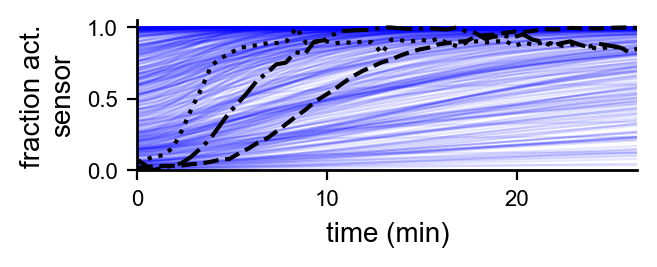

In [77]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MA_non.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MA_nonessential_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_nonessential.pdf', bbox_inches='tight', transparent=True)

betaAMP 1.2, 0.45
alphaPP 1.2, 0.45
alphaLKB1 -4, 2.45

In [110]:
pz.predictive_explorer(construct_pm_model_MA_non, plot_func=plot_func_trajectories, samples=40)

In [81]:
prior_new_MA_nonessential = {
    'kOffAMP':    {'mu': -3,  'sigma': 1.5},
    'kOffADP':    {'mu': -3,  'sigma': 1.5},
    'kOffATP':    {'mu': -5.5,  'sigma': 1},
    'kOffCaMKK':  {'mu': -1,  'sigma': 2},
    'kPhosCaMKK': {'mu': -3.5,  'sigma': 2},
    'kOffLKB1':   {'mu': -1,  'sigma': 2},
    'alphaLKB1':  {'mu': 0,  'sigma': 3},
    'kPhosLKB1':  {'mu': -3.5,  'sigma': 2},
    'kOffPP':     {'mu': -1,  'sigma': 1},
    'alphaPP':    {'mu': 1.5,  'sigma': 1.5},
    'kDephosPP':  {'mu': -7,  'sigma': 3},
    'kOffAMPK':   {'mu': 2.5,  'sigma': 1},
    'kPhosAMPK':  {'mu': -3,  'sigma': 1},
    'betaAMP':    {'mu': 1.5,  'sigma': 1.5},
    'kOffPP1':    {'mu': 0,  'sigma': 1},
    'kDephosPP1': {'mu': -13,  'sigma': 6}
}

In [82]:
MA_non_pm_model_updated = construct_pm_model_MA_non(
    kOffAMP_mu=prior_new_MA_nonessential['kOffAMP']['mu'],
    kOffAMP_sigma=prior_new_MA_nonessential['kOffAMP']['sigma'],
    kOffADP_mu=prior_new_MA_nonessential['kOffADP']['mu'],
    kOffADP_sigma=prior_new_MA_nonessential['kOffADP']['sigma'],
    kOffATP_mu=prior_new_MA_nonessential['kOffATP']['mu'],
    kOffATP_sigma=prior_new_MA_nonessential['kOffATP']['sigma'],
    kOffCaMKK_mu=prior_new_MA_nonessential['kOffCaMKK']['mu'],
    kOffCaMKK_sigma=prior_new_MA_nonessential['kOffCaMKK']['sigma'],
    kPhosCaMKK_mu=prior_new_MA_nonessential['kPhosCaMKK']['mu'],
    kPhosCaMKK_sigma=prior_new_MA_nonessential['kPhosCaMKK']['sigma'],
    kOffLKB1_mu=prior_new_MA_nonessential['kOffLKB1']['mu'],
    kOffLKB1_sigma=prior_new_MA_nonessential['kOffLKB1']['sigma'],
    alphaLKB1_mu=prior_new_MA_nonessential['alphaLKB1']['mu'],
    alphaLKB1_sigma=prior_new_MA_nonessential['alphaLKB1']['sigma'],
    kPhosLKB1_mu=prior_new_MA_nonessential['kPhosLKB1']['mu'],
    kPhosLKB1_sigma=prior_new_MA_nonessential['kPhosLKB1']['sigma'],
    kOffPP_mu=prior_new_MA_nonessential['kOffPP']['mu'],
    kOffPP_sigma=prior_new_MA_nonessential['kOffPP']['sigma'],
    alphaPP_mu=prior_new_MA_nonessential['alphaPP']['mu'],
    alphaPP_sigma=prior_new_MA_nonessential['alphaPP']['sigma'],
    kDephosPP_mu=prior_new_MA_nonessential['kDephosPP']['mu'],
    kDephosPP_sigma=prior_new_MA_nonessential['kDephosPP']['sigma'],
    kOffAMPK_mu=prior_new_MA_nonessential['kOffAMPK']['mu'],
    kOffAMPK_sigma=prior_new_MA_nonessential['kOffAMPK']['sigma'],
    kPhosAMPK_mu=prior_new_MA_nonessential['kPhosAMPK']['mu'],
    kPhosAMPK_sigma=prior_new_MA_nonessential['kPhosAMPK']['sigma'],
    betaAMP_mu=prior_new_MA_nonessential['betaAMP']['mu'],
    betaAMP_sigma=prior_new_MA_nonessential['betaAMP']['sigma'],
    kOffPP1_mu=prior_new_MA_nonessential['kOffPP1']['mu'],
    kDephosPP1_mu=prior_new_MA_nonessential['kDephosPP1']['mu'],
    kDephosPP1_sigma=prior_new_MA_nonessential['kDephosPP1']['sigma']
)
with MA_non_pm_model_updated:
    prior_pred_MA_non_updated = pm.sample_prior_predictive(samples=500)

Sampling: [alphaLKB1, alpha_pp, betaAMP, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


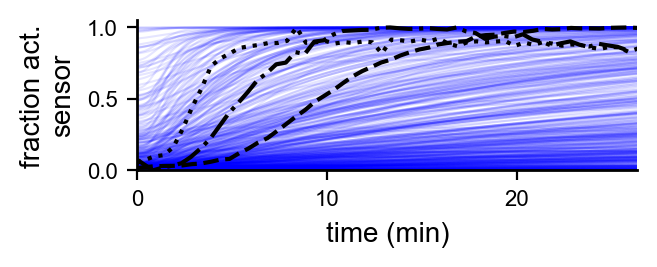

In [84]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MA_non_updated.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
# export_legend(leg, savedir + 'prior_pred_MA_nonessential_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_nonessential_updated.pdf', bbox_inches='tight', transparent=True)

In [113]:
MM_non_pm_model = construct_pm_model_MM_non()
with MM_non_pm_model:
    prior_pred_MM_non = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, alphaLKB1, alphaPP, betaAMP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


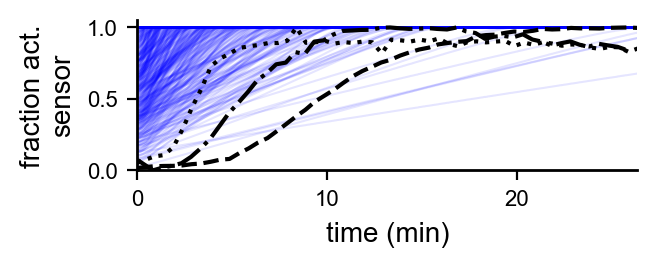

In [114]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MM_non.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
# export_legend(leg, savedir + 'prior_pred_MA_nonessential_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MM_nonessential.pdf', bbox_inches='tight', transparent=True)

That looks okay, lets try with the priors identified for the MA nonessential model

In [115]:
MM_non_pm_model_updated = construct_pm_model_MM_non(alphaLKB1_mu=0, alphaLKB1_sigma=3,
                                            alphaPP_mu=1.5, alphaPP_sigma=1.5,
                                            betaAMP_mu=1.5, betaAMP_sigma=1.5)
with MM_non_pm_model_updated:
    prior_pred_MM_non_updated = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, alphaLKB1, alphaPP, betaAMP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


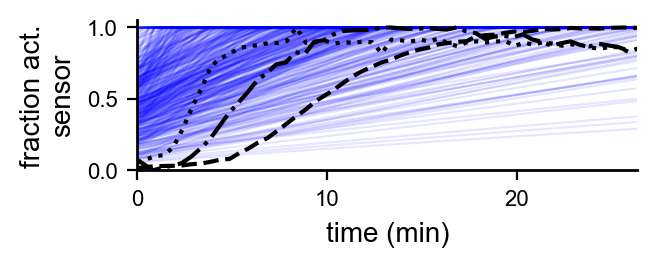

In [116]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MM_non_updated.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
# export_legend(leg, savedir + 'prior_pred_MA_nonessential_legend.pdf')
leg.remove()
# # fig.tight_layout()
# fig.savefig(savedir + 'prior_pred_MM_nonessential_updated.pdf', bbox_inches='tight', transparent=True)

In [131]:
prior_new_MM_nonessential = {
    'kOffAMP':    {'mu': -5.5,  'sigma': 1},
    'kOffADP':    {'mu': -5.5,  'sigma': 1},
    'kOffATP':    {'mu': -5.5,  'sigma': 1},
    'kCaMKK':  {'mu': -3,  'sigma': 1},
    'KmCaMKK': {'mu': 0,  'sigma': 1},
    'kLKB1':   {'mu': -3,  'sigma': 1},
    'KmLKB1':  {'mu': 5,  'sigma': 1},
    'alphaLKB1':  {'mu': 0,  'sigma': 3},
    'kPP':     {'mu': -2,  'sigma': 1},
    'KmPP':  {'mu': 1,  'sigma': 3},
    'alphaPP':    {'mu': 1.5,  'sigma': 1.5},
    'betaAMP':    {'mu': 1.5,  'sigma': 1.5},
}

In [129]:
pz.predictive_explorer(construct_pm_model_MM_non, plot_func=plot_func_trajectories, samples=40)

In [132]:
MM_non_pm_model_updated = construct_pm_model_MM_non(
    kOffAMP_mu=prior_new_MM_nonessential['kOffAMP']['mu'],
    kOffAMP_sigma=prior_new_MM_nonessential['kOffAMP']['sigma'],
    kOffADP_mu=prior_new_MM_nonessential['kOffADP']['mu'],
    kOffADP_sigma=prior_new_MM_nonessential['kOffADP']['sigma'],
    kOffATP_mu=prior_new_MM_nonessential['kOffATP']['mu'],
    kOffATP_sigma=prior_new_MM_nonessential['kOffATP']['sigma'],
    kCaMKK_mu=prior_new_MM_nonessential['kCaMKK']['mu'],
    kCaMKK_sigma=prior_new_MM_nonessential['kCaMKK']['sigma'],
    Km_CaMKK_mu=prior_new_MM_nonessential['KmCaMKK']['mu'],
    Km_CaMKK_sigma=prior_new_MM_nonessential['KmCaMKK']['sigma'],
    kLKB1_mu=prior_new_MM_nonessential['kLKB1']['mu'],
    kLKB1_sigma=prior_new_MM_nonessential['kLKB1']['sigma'],
    KmLKB1_mu=prior_new_MM_nonessential['KmLKB1']['mu'],
    KmLKB1_sigma=prior_new_MM_nonessential['KmLKB1']['sigma'],
    alphaLKB1_mu=prior_new_MM_nonessential['alphaLKB1']['mu'],
    alphaLKB1_sigma=prior_new_MM_nonessential['alphaLKB1']['sigma'],
    kPP_mu=prior_new_MM_nonessential['kPP']['mu'],
    kPP_sigma=prior_new_MM_nonessential['kPP']['sigma'],
    KmPP_mu=prior_new_MM_nonessential['KmPP']['mu'],
    KmPP_sigma=prior_new_MM_nonessential['KmPP']['sigma'],
    alphaPP_mu=prior_new_MM_nonessential['alphaPP']['mu'],
    alphaPP_sigma=prior_new_MM_nonessential['alphaPP']['sigma'],
    betaAMP_mu=prior_new_MM_nonessential['betaAMP']['mu'],
    betaAMP_sigma=prior_new_MM_nonessential['betaAMP']['sigma']
)

with MM_non_pm_model_updated:
    prior_pred_MM_non_updated = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, alphaLKB1, alphaPP, betaAMP, kCaMKK, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


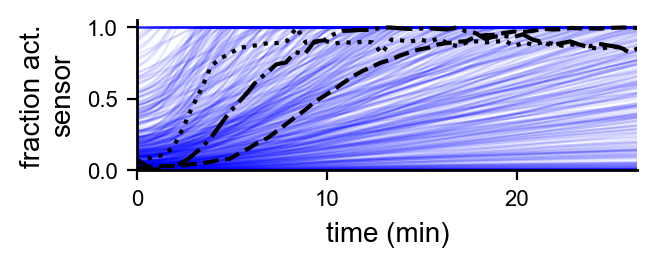

In [133]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MM_non_updated.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
# export_legend(leg, savedir + 'prior_pred_MA_nonessential_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MM_nonessential.pdf', bbox_inches='tight', transparent=True)

That looks better, we will use that for the MM nonessential model.

In [134]:
##### MA_nonessential
# need the bounds and prior params for alphaLKB1, alphaPP and betaAMP
MA_nonessential_info = json.load(open('../models/MA_nonessential.json'))
nonessential_params = ['alphaLKB1', 'alphaPP', 'betaAMP']

# bounds
MA_nonessential_bounds_updated = MA_non_info['param_bounds'].copy()
for param in list(prior_new_MA_nonessential.keys()):
    MA_nonessential_bounds_updated[param] = list(pz.LogNormal(
        prior_new_MA_nonessential[param]['mu'], 
        prior_new_MA_nonessential[param]['sigma']).hdi(0.95, fmt='.8f'))

# priors
MA_nonessential_prior_params_updated = MA_non_info['prior_params'].copy()
for param in list(prior_new_MA_nonessential.keys()):
    MA_nonessential_prior_params_updated[param] = prior_new_MA_nonessential[param]

# update the model info file with the new bounds
MA_nonessential_info['param_bounds'] =  MA_nonessential_bounds_updated
MA_nonessential_info['prior_params'] = MA_nonessential_prior_params_updated

# save the updated model info
with open('../models/MA_nonessential.json', 'w') as file:
    json.dump(MA_nonessential_info, file, indent=4)

##### MM_nonessential
# need the bounds and prior params for alphaLKB1, alphaPP and betaAMP
MM_nonessential_info = json.load(open('../models/MM_nonessential.json'))

# bounds
MM_nonessential_bounds_updated = MM_non_info['param_bounds'].copy()
for param in list(prior_new_MM_nonessential.keys()):
    MM_nonessential_bounds_updated[param] = list(pz.LogNormal(
        prior_new_MM_nonessential[param]['mu'], 
        prior_new_MM_nonessential[param]['sigma']).hdi(0.95, fmt='.8f'))

# priors
MM_nonessential_prior_params_updated = MM_non_info['prior_params'].copy()
for param in list(prior_new_MM_nonessential.keys()):
    MM_nonessential_prior_params_updated[param] = prior_new_MM_nonessential[param]


# update the model info file with the new bounds
MM_nonessential_info['param_bounds'] =  MM_nonessential_bounds_updated
MM_nonessential_info['prior_params'] = MM_nonessential_prior_params_updated

# save the updated model info
with open('../models/MM_nonessential.json', 'w') as file:
    json.dump(MM_nonessential_info, file, indent=4)

For the `AMPK_Coccimiglio` model, we will just use the priors elicited from the original bounds...

In [85]:
AMPK_coccimiglio_info = json.load(open('../models/AMPK_coccimiglio.json'))
AMPK_coccimiglio_info['prior_params'] = prior_params['ampk_Coccimiglio'].copy()
AMPK_coccimiglio_info['param_bounds'] = AMPK_coccimiglio_info['param_bounds_original'].copy()

# save the updated model info
with open('../models/AMPK_coccimiglio.json', 'w') as file:
    json.dump(AMPK_coccimiglio_info, file, indent=4)